#### __`Importing Libraries, Setting Display Options`__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import percentileofscore

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))     # To view numerical values in dataframe columns uniformly
pd.set_option('display.max_columns', None)                              # To view all columns in .describe() 

---
---
> Train-Test Split before everything
---
> Feature Cleaning
- NaN Values
- Duplicates
- Outliers
- Class Imbalance

> Feature Transformation
- Scaling
- Encoding

> Feature Engineering
- Feature Selection / Elimination
- Feature Creation / Extraction
---
---

#### __`Data Loading`__

In [2]:
readDF = pd.read_excel('training_data/premiums.xlsx')

In [3]:
df = readDF.copy()
df

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,9490


#### __`Data Cleaning`__

##### Features : Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    50000 non-null  int64 
 1   Gender                 50000 non-null  object
 2   Region                 50000 non-null  object
 3   Marital_status         50000 non-null  object
 4   Number Of Dependants   50000 non-null  int64 
 5   BMI_Category           50000 non-null  object
 6   Smoking_Status         49989 non-null  object
 7   Employment_Status      49998 non-null  object
 8   Income_Level           49987 non-null  object
 9   Income_Lakhs           50000 non-null  int64 
 10  Medical History        50000 non-null  object
 11  Insurance_Plan         50000 non-null  object
 12  Annual_Premium_Amount  50000 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.0+ MB


* `Target is 'int', as expected`
* `Let's move to Features`

In [5]:
df.columns = df.columns.str.lower().str.replace(' ','_')
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

In [6]:
df.dtypes

age                       int64
gender                   object
region                   object
marital_status           object
number_of_dependants      int64
bmi_category             object
smoking_status           object
employment_status        object
income_level             object
income_lakhs              int64
medical_history          object
insurance_plan           object
annual_premium_amount     int64
dtype: object

In [7]:
df.dtypes.unique()

array([dtype('int64'), dtype('O')], dtype=object)

In [8]:
temp = pd.DataFrame(df.drop(columns=['annual_premium_amount']).dtypes).reset_index()
temp.columns = ['feature_name','feature_type']

num_features = list(temp[temp['feature_type'].astype(str).isin(['int64'])]['feature_name'])
cat_features = list(temp[temp['feature_type'].astype(str).isin(['object'])]['feature_name'])

print(f'Total Features       : {df.shape[1]-1}', '\n')

print(f'Numerical Features   : {len(num_features)}   ', num_features)
print(f'Categorical Features : {len(cat_features)}   ', cat_features)

Total Features       : 12 

Numerical Features   : 3    ['age', 'number_of_dependants', 'income_lakhs']
Categorical Features : 9    ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'medical_history', 'insurance_plan']


##### NaN Values

In [9]:
df.isnull().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [10]:
df[df.isnull().any(axis=1)]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
177,26,Female,Southwest,Married,3,Underweight,NaN,Salaried,> 40L,69,Diabetes,Gold,22605
997,20,Female,Southeast,Unmarried,0,Normal,No Smoking,Self-Employed,NaN,5,No Disease,Bronze,7191
7094,33,Male,Southeast,Married,2,Normal,Regular,Self-Employed,NaN,7,High blood pressure,Silver,18335
15395,27,Female,Northeast,Unmarried,2,Underweight,No Smoking,Freelancer,NaN,5,No Disease,Silver,14469
15452,52,Male,Northeast,Married,3,Underweight,No Smoking,Freelancer,NaN,8,Thyroid,Silver,19535
15648,47,Male,Southwest,Married,4,Normal,NaN,Freelancer,25L - 40L,32,Diabetes,Gold,26100
16324,45,Male,Northwest,Married,4,Overweight,NaN,Salaried,10L - 25L,16,High blood pressure & Heart disease,Silver,21881
16941,34,Male,Southwest,Married,5,Normal,NaN,Self-Employed,25L - 40L,35,High blood pressure & Heart disease,Gold,25865
16975,23,Male,Southwest,Unmarried,0,Normal,NaN,Freelancer,<10L,3,No Disease,Bronze,6001
17438,40,Female,Northeast,Married,4,Obesity,Regular,Self-Employed,NaN,8,High blood pressure,Silver,22392


* `Dropping Rows with NaN as the count is too low`

In [11]:
df = df.dropna().reset_index(drop=True)
print(df.isnull().sum())
print('\n SHAPE : ', df.shape)

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

 SHAPE :  (49976, 13)


##### Checking for Duplicates

In [12]:
# There's no Primary Key, so checking with .dupicated().sum()

df.duplicated().sum()

0

##### Checking Numerical Columns for inconsistencies

In [13]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.00,49976.00,49976.00,49976.00
mean,34.59,1.71,23.02,15766.81
std,15.00,1.50,24.22,8420.00
min,18.00,-3.00,1.00,3501.00
25%,22.00,0.00,7.00,8607.75
50%,31.00,2.00,17.00,13928.00
75%,45.00,3.00,31.00,22273.50
max,356.00,5.00,930.00,43471.00


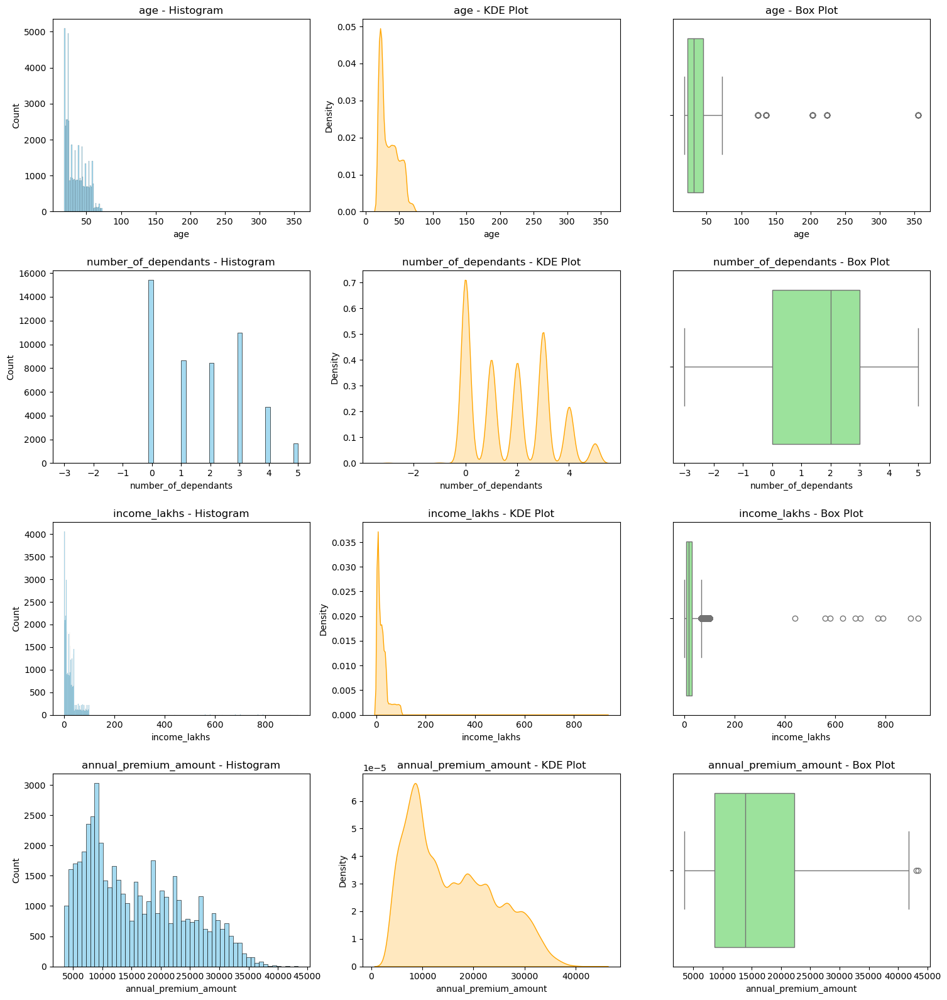

In [14]:
# for i in num_features+['annual_premium_amount']:
#     sns.boxplot(x=df[i])
#     plt.show()

# Customized the visualization using ChatGPT

def plot_num_features(df, num_features):
    # Number of features
    n = len(num_features)+1
    
    # Create a figure with n rows and 3 columns
    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(15, 4 * n))

    # If there's only one feature, axes will not be a 2D array, so fix that
    if n == 1:
        axes = axes.reshape(1, 3)

    for i, col in enumerate(num_features+['annual_premium_amount']):
        # Histogram
        sns.histplot(df[col], ax=axes[i, 0], kde=False, color="skyblue")
        axes[i, 0].set_title(f"{col} - Histogram")

        # KDE plot
        sns.kdeplot(df[col], ax=axes[i, 1], fill=True, color="orange")
        axes[i, 1].set_title(f"{col} - KDE Plot")

        # Boxplot
        sns.boxplot(x=df[col], ax=axes[i, 2], color="lightgreen")
        axes[i, 2].set_title(f"{col} - Box Plot")

    plt.tight_layout()
    plt.show()
plot_num_features(df, num_features)

`age`

In [15]:
# age has outliers since it can't be 356

<Axes: xlabel='age', ylabel='Count'>

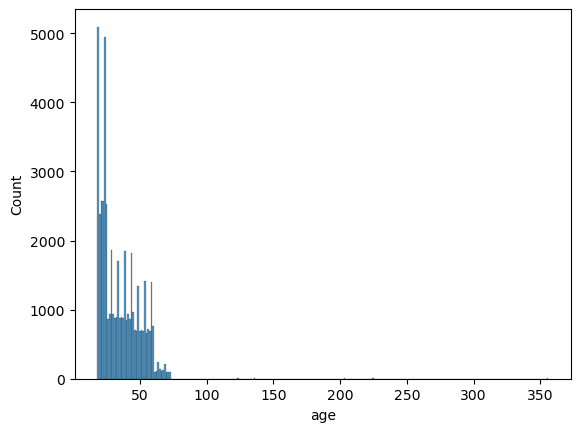

In [16]:
sns.histplot(df['age'])

In [17]:
df['age'].value_counts().tail(10)

age
71     104
70     104
72     102
61     100
68      85
136     15
203     13
124     11
224     10
356      9
Name: count, dtype: int64

In [18]:
print(df[df['age']>100].shape)
print(df[df['age']>90].shape)
print(df[df['age']>80].shape)
print(df[df['age']>70].shape)

(58, 13)
(58, 13)
(58, 13)
(264, 13)


In [19]:
print(df['age'].quantile(0.95))
print(df['age'].quantile(0.99))
print(df['age'].quantile(0.999))

59.0
69.0
124.0


In [20]:
print(percentileofscore(df['age'], 100))
print(percentileofscore(df['age'], 70))

99.88394429326075
99.36869697454777


In [21]:
# Let's keep 'age' realistic and drop ages below 100

df = df[df['age']<100].reset_index(drop=True)

In [22]:
df.shape

(49918, 13)

`number_of_dependants`

In [23]:
# number_of_dependants can't be negative

In [24]:
df['number_of_dependants'].value_counts()

number_of_dependants
 0    15409
 3    10994
 1     8661
 2     8409
 4     4722
 5     1651
-1       40
-3       32
Name: count, dtype: int64

In [25]:
df['number_of_dependants'] = np.abs(df['number_of_dependants'])             # can also do   abs(df['number_of_dependants'])

In [26]:
df['number_of_dependants'].value_counts()

number_of_dependants
0    15409
3    11026
1     8701
2     8409
4     4722
5     1651
Name: count, dtype: int64

`income_lakhs`

In [27]:
# Let's check for Outliers since 75th percentile is a lot smaller than max

<Axes: xlabel='income_lakhs', ylabel='Count'>

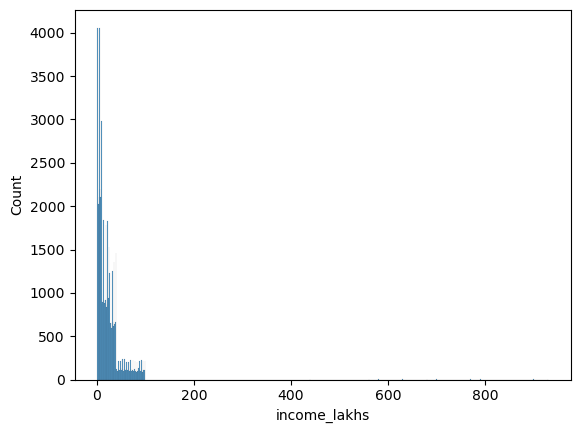

In [28]:
sns.histplot(df['income_lakhs'])

<Axes: xlabel='income_lakhs', ylabel='Count'>

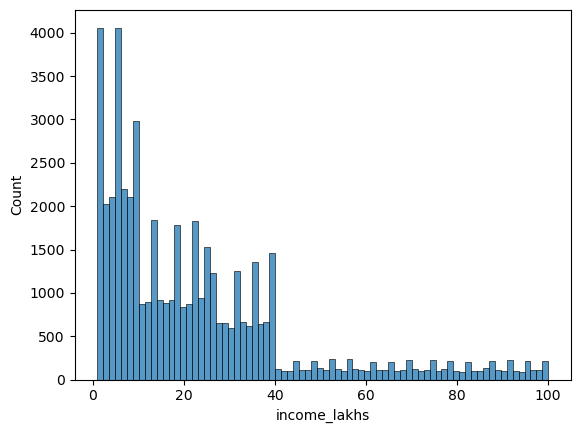

In [29]:
sns.histplot(df[df['income_lakhs']<150]['income_lakhs'])

In [30]:
df[df['income_lakhs']>100]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
2627,51,Male,Northwest,Married,4,Obesity,No Smoking,Self-Employed,> 40L,560,High blood pressure,Gold,30692
4211,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,440,No Disease,Silver,10636
7761,35,Female,Northeast,Unmarried,0,Overweight,No Smoking,Salaried,> 40L,630,Diabetes,Gold,24010
9005,43,Male,Southeast,Married,3,Obesity,Regular,Salaried,> 40L,900,Diabetes & Thyroid,Gold,30848
10321,37,Female,Southeast,Married,3,Normal,No Smoking,Freelancer,> 40L,930,Diabetes,Silver,15945
10623,20,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,580,Thyroid,Silver,12888
11439,21,Female,Southwest,Unmarried,0,Obesity,No Smoking,Freelancer,> 40L,700,No Disease,Bronze,7424
15413,21,Female,Southeast,Unmarried,0,Normal,Occasional,Salaried,> 40L,790,No Disease,Silver,7586
35385,59,Male,Northwest,Married,2,Obesity,Occasional,Self-Employed,> 40L,770,Thyroid,Gold,31115
40898,48,Male,Northeast,Married,4,Obesity,No Smoking,Salaried,> 40L,680,No Disease,Gold,28926


In [31]:
# Since they're all outliers, let's drop income above 100 Lakhs

In [32]:
print(df['income_lakhs'].quantile(0.95))
print(df['income_lakhs'].quantile(0.99))
print(df['income_lakhs'].quantile(0.999))

77.0
96.0
100.0


In [33]:
percentileofscore(df['income_lakhs'], 100)

99.88080451941183

In [34]:
df = df[df['income_lakhs']<=100].reset_index(drop=True)

In [35]:
df.shape

(49908, 13)

`Target : annual_premium_amount`

In [36]:
df[df['annual_premium_amount']>40000]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
6377,71,Male,Southeast,Married,1,Underweight,Regular,Salaried,10L - 25L,17,High blood pressure & Heart disease,Gold,40063
9900,63,Female,Southwest,Unmarried,0,Obesity,Regular,Self-Employed,10L - 25L,23,Heart disease,Gold,43119
14116,69,Female,Southwest,Married,2,Overweight,Regular,Self-Employed,> 40L,44,Heart disease,Gold,41317
16419,69,Male,Northeast,Married,1,Overweight,Regular,Self-Employed,25L - 40L,25,Heart disease,Gold,41556
19877,65,Male,Northwest,Married,1,Overweight,Regular,Self-Employed,10L - 25L,20,Heart disease,Gold,41658
22603,72,Female,Southwest,Married,1,Obesity,Regular,Self-Employed,10L - 25L,18,Diabetes & High blood pressure,Gold,41848
29480,68,Male,Southwest,Married,1,Underweight,Regular,Self-Employed,10L - 25L,10,Heart disease,Gold,40138
29567,67,Male,Southeast,Married,1,Overweight,Regular,Self-Employed,> 40L,57,Heart disease,Gold,41461
31449,63,Male,Northwest,Unmarried,0,Obesity,No Smoking,Self-Employed,10L - 25L,21,Heart disease,Gold,40478
46036,71,Male,Northwest,Married,2,Obesity,Regular,Self-Employed,10L - 25L,24,Heart disease,Gold,43471


In [37]:
# It seems that extraordinary high annual_premium_account is because of smoking_status, health_heart_disease, age and insurance_plan, i.e., old-aged regular smokers with heart condition with Gold plan
# Don't seem like anomalies, so let them stay

In [38]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49908.00,49908.00,49908.00,49908.00
mean,34.40,1.72,22.89,15765.74
std,13.68,1.49,22.17,8418.67
min,18.00,0.00,1.00,3501.00
25%,22.00,0.00,7.00,8608.00
50%,31.00,2.00,17.00,13928.00
75%,45.00,3.00,31.00,22270.50
max,72.00,5.00,100.00,43471.00


In [39]:
# Looks fine, let's move to Categorical Columns

##### Checking Categorical Columns for inconsistencies

In [40]:
for feature in cat_features:
    print(df[feature].value_counts(), '\n')

gender
Male      27431
Female    22477
Name: count, dtype: int64 

region
Southeast    17487
Southwest    15124
Northwest    10028
Northeast     7269
Name: count, dtype: int64 

marital_status
Unmarried    25630
Married      24278
Name: count, dtype: int64 

bmi_category
Normal         23469
Overweight     11541
Underweight     7752
Obesity         7146
Name: count, dtype: int64 

smoking_status
No Smoking        27321
Regular           15664
Occasional         6901
Smoking=0             8
Not Smoking           8
Does Not Smoke        6
Name: count, dtype: int64 

employment_status
Salaried         20932
Freelancer       15399
Self-Employed    13577
Name: count, dtype: int64 

income_level
<10L         18643
10L - 25L    14369
25L - 40L    10273
> 40L         6623
Name: count, dtype: int64 

medical_history
No Disease                             21138
Diabetes                                9533
High blood pressure                     7209
Thyroid                                 4917
H

`smoking_status`

In [41]:
df.loc[~df['smoking_status'].isin(['No Smoking','Occasional','Regular']), 'smoking_status'] = 'No Smoking'

`income_level`

In [42]:
# Since 'income_level' is simply derived from 'income_lakhs', it will cause multi-collinearity
# But since this classification is important for the client while assessing a loan application, we should utilize this  ...
#       ... and see what types of results we get if we use 'income_level' instead of 'income_lakhs'                     ...
#       ... (A freelancer/self-employed person might only be able to provide a range of income)

In [43]:
for x in df['income_level'].unique():
    print(x, ' --->    min:', df[df['income_level']==x]['income_lakhs'].min(), ',', 'max:', df[df['income_level']==x]['income_lakhs'].max())

<10L  --->    min: 1 , max: 9
10L - 25L  --->    min: 10 , max: 25
> 40L  --->    min: 40 , max: 100
25L - 40L  --->    min: 25 , max: 40


In [44]:
print(df[df['income_lakhs']==25]['income_level'].value_counts(), '\n')
print(df[df['income_lakhs']==40]['income_level'].value_counts())

income_level
10L - 25L    894
25L - 40L    630
Name: count, dtype: int64 

income_level
25L - 40L    660
> 40L        111
Name: count, dtype: int64


In [45]:
# This categorization is not consistent since 25 is present in multiple bins and 40 is present in multiple bins 
# Talk to the client to understand how this categorization should exactly be like

In [46]:
df['income_level'].value_counts()

income_level
<10L         18643
10L - 25L    14369
25L - 40L    10273
> 40L         6623
Name: count, dtype: int64

In [47]:
df.loc[df['income_lakhs']<10, 'income_level'] = '< 10L'
df.loc[(df['income_lakhs']>=10) & (df['income_lakhs']<25), 'income_level'] = '10L - 25L'
df.loc[(df['income_lakhs']>=25) & (df['income_lakhs']<=40), 'income_level'] = '25L - 40L'
df.loc[df['income_lakhs']>40, 'income_level'] = '> 40L'

In [48]:
df['income_level'].value_counts()

income_level
< 10L        18643
10L - 25L    13475
25L - 40L    11278
> 40L         6512
Name: count, dtype: int64

`medical_history`

In [49]:
df.shape

(49908, 13)

In [50]:
df['health_no_disease']     = 0
df['health_diabetes']       = 0
df['health_high_bp']        = 0
df['health_thyroid']        = 0
df['health_heart_disease']  = 0

df.loc[df['medical_history'].str.contains('No Disease'), 'health_no_disease'] = 1
df.loc[df['medical_history'].str.contains('Diabetes'), 'health_diabetes'] = 1
df.loc[df['medical_history'].str.contains('High blood pressure'), 'health_high_bp'] = 1
df.loc[df['medical_history'].str.contains('Thyroid'), 'health_thyroid'] = 1
df.loc[df['medical_history'].str.contains('Heart disease'), 'health_heart_disease'] = 1

new_added_columns = ['health_no_disease', 'health_diabetes', 'health_high_bp', 'health_thyroid', 'health_heart_disease']

In [51]:
df.drop(columns = ['medical_history'], inplace=True)

In [52]:
print(len(cat_features), ' Categorical Features \n', cat_features)

9  Categorical Features 
 ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'medical_history', 'insurance_plan']


In [53]:
cat_features += new_added_columns
cat_features.remove('medical_history')

print(len(cat_features), ' Categorical Features \n', cat_features)

13  Categorical Features 
 ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'insurance_plan', 'health_no_disease', 'health_diabetes', 'health_high_bp', 'health_thyroid', 'health_heart_disease']


In [54]:
df.shape

(49908, 17)

In [55]:
for i in new_added_columns:
    print(df[i].value_counts(), '\n')

health_no_disease
0    28770
1    21138
Name: count, dtype: int64 

health_diabetes
0    36880
1    13028
Name: count, dtype: int64 

health_high_bp
0    39785
1    10123
Name: count, dtype: int64 

health_thyroid
0    43876
1     6032
Name: count, dtype: int64 

health_heart_disease
0    45553
1     4355
Name: count, dtype: int64 



#### __`Feature Engineering : Feature Creation`__

In [56]:
# INPUT FROM BUSINESS
# -----------------------------------
#   Risk scores for health conditions
#       No Disease      :   0
#       Diabetes        :   6
#       High BP         :   6
#       Thyroid         :   5
#       Heart Disease   :   8
# -----------------------------------
#   MIN : 0
#   MAX : 25
# -----------------------------------

In [57]:
# Creating a new combined feature : health_risk_score

df['health_risk_score'] = (6 * df['health_diabetes']) + (6 * df['health_high_bp']) + (5 * df['health_thyroid']) + (8 * df['health_heart_disease'])


# I'm doing the below step to normalise health_risk_score on a scale of 0-25, i.e. (min-max)
# The Train Data might be missing the case of 'health_risk_score = 25' but it's theoretically possible

df['health_risk_score'] = df['health_risk_score'] / 25      
                                                            
df.drop(columns=['health_no_disease', 'health_diabetes', 'health_high_bp', 'health_thyroid', 'health_heart_disease'], inplace=True)

In [58]:
df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,health_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,< 10L,6,Bronze,9053,0.24
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,< 10L,6,Bronze,16339,0.24
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,Silver,18164,0.24
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,Gold,20303,0.00
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,Silver,13365,0.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49903,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,Bronze,9111,0.00
49904,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Gold,27076,0.20
49905,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,Bronze,8564,0.00
49906,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,Bronze,9490,0.00


In [59]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'insurance_plan', 'annual_premium_amount',
       'health_risk_score'],
      dtype='object')

In [60]:
num_features = ['age', 'number_of_dependants', 'income_lakhs', 'health_risk_score']
cat_features = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'insurance_plan']

In [61]:
print(len(num_features), num_features)
print(len(cat_features), cat_features)

4 ['age', 'number_of_dependants', 'income_lakhs', 'health_risk_score']
8 ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'insurance_plan']


In [62]:
df['health_risk_score'].describe()

count   49908.00
mean        0.16
std         0.16
min         0.00
25%         0.00
50%         0.20
75%         0.24
max         0.56
Name: health_risk_score, dtype: float64

#### __`EDA`__

##### `Uni-Variate`

In [63]:
print(len(df.columns), df.columns)
print(len(num_features), num_features)
print(len(cat_features), cat_features)

13 Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'insurance_plan', 'annual_premium_amount',
       'health_risk_score'],
      dtype='object')
4 ['age', 'number_of_dependants', 'income_lakhs', 'health_risk_score']
8 ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'insurance_plan']


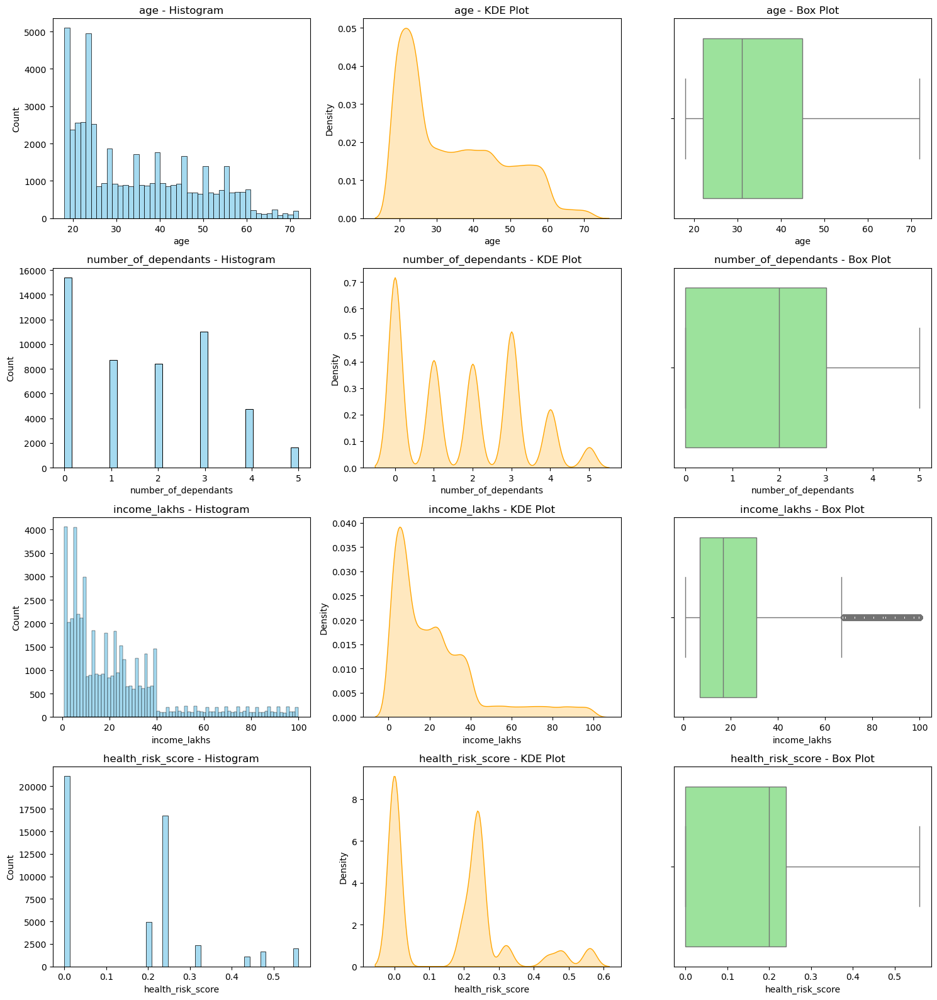

In [64]:
def plot_num_features(df, num_features):
    # Number of features
    n = len(num_features)
    
    # Create a figure with n rows and 3 columns
    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(15, 4 * n))

    # If there's only one feature, axes will not be a 2D array, so fix that
    if n == 1:
        axes = axes.reshape(1, 3)

    for i, col in enumerate(num_features):
        # Histogram
        sns.histplot(df[col], ax=axes[i, 0], kde=False, color="skyblue")
        axes[i, 0].set_title(f"{col} - Histogram")

        # KDE plot
        sns.kdeplot(df[col], ax=axes[i, 1], fill=True, color="orange")
        axes[i, 1].set_title(f"{col} - KDE Plot")

        # Boxplot
        sns.boxplot(x=df[col], ax=axes[i, 2], color="lightgreen")
        axes[i, 2].set_title(f"{col} - Box Plot")

    plt.tight_layout()
    plt.show()
plot_num_features(df, num_features)

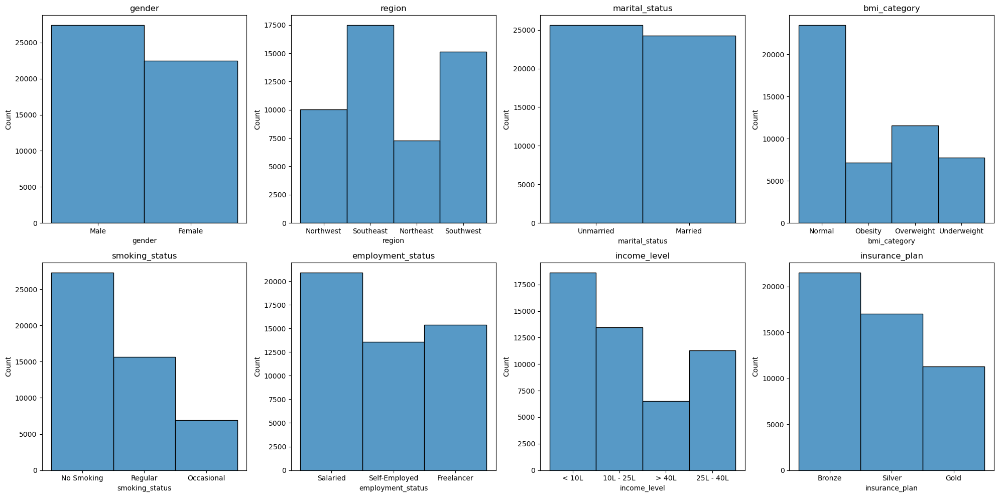

In [ ]:
# BETTER VISUALIZATION IN THE CELL BELOW (PERCENT DISTRIBUTION)

cols = 4                                            # Number of columns per row
n = len(cat_features)
rows = (n // cols) + int(n % cols != 0)
plt.figure(figsize=(cols*5, rows*5))                # Adjust height per row
for i, feature in enumerate(cat_features, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[feature])
    plt.title(feature)
    plt.tight_layout()

plt.show()

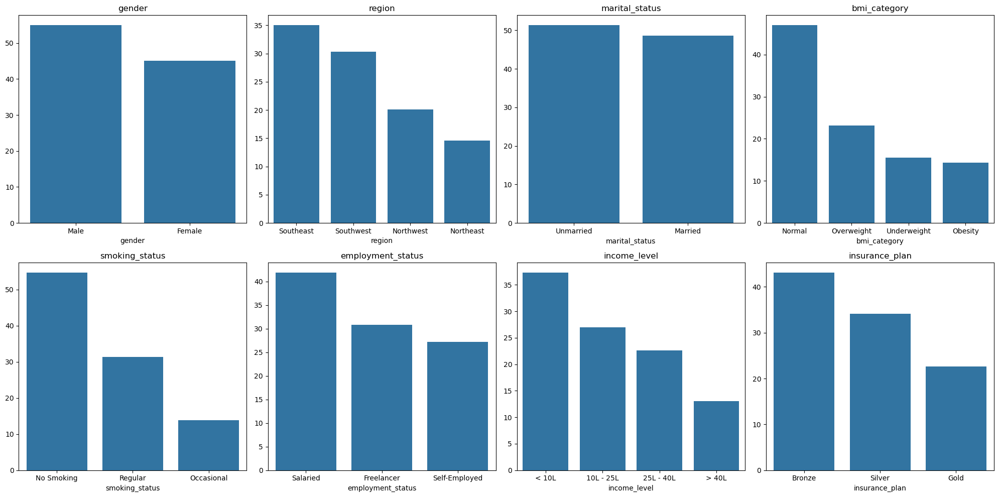

In [66]:
cols = 4                                            # Number of columns per row
n = len(cat_features)
rows = (n // cols) + int(n % cols != 0)
plt.figure(figsize=(cols*5, rows*5))                # Adjust height per row
for i, feature in enumerate(cat_features, 1):
    plt.subplot(rows, cols, i)
    
    percentages = df[feature].value_counts(normalize=True) * 100                # To view percent distribution
    sns.barplot(
        x=percentages.index,
        y=percentages.values
    )
    
    plt.title(feature)
    plt.tight_layout()

plt.show()

##### `Bi-variate`

---
Numerical vs Numerical


In [67]:
df[num_features + ['annual_premium_amount']].corr()

,age,number_of_dependants,income_lakhs,health_risk_score,annual_premium_amount
age,1.00,0.42,0.03,0.44,0.77
number_of_dependants,0.42,1.00,0.01,0.37,0.41
income_lakhs,0.03,0.01,1.00,0.01,0.24
health_risk_score,0.44,0.37,0.01,1.00,0.52
annual_premium_amount,0.77,0.41,0.24,0.52,1.00


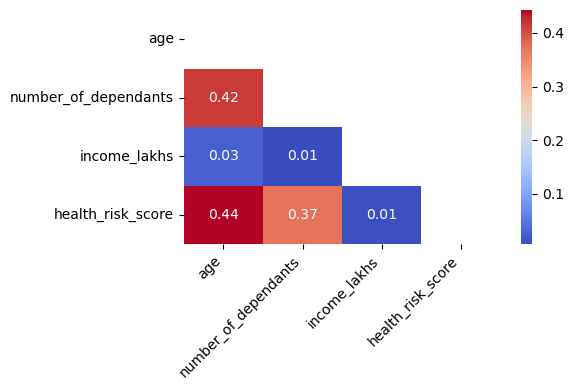

In [72]:
plt.figure(figsize=(6,4))

sns.heatmap(np.abs(df[num_features].corr()),
            fmt='0.2f',
            mask = np.triu(np.ones_like(np.abs(df[num_features].corr()), dtype=bool)),
            cmap='coolwarm',
            annot=True
            )

plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout()
plt.show()

---
Categorical vs Target

In [73]:
# Categorical features vs Target

for feature in cat_features:
    print(df.groupby(feature)['annual_premium_amount'].describe().to_string(), '\n')

          count     mean     std     min     25%      50%      75%      max
gender                                                                     
Female 22477.00 15166.16 8040.96 3501.00 8563.00 13099.00 21105.00 43119.00
Male   27431.00 16257.04 8685.33 3503.00 8650.00 14935.00 22820.00 43471.00 

             count     mean     std     min     25%      50%      75%      max
region                                                                        
Northeast  7269.00 15757.93 8388.69 3508.00 8583.00 14053.00 22215.00 41556.00
Northwest 10028.00 15680.49 8409.78 3512.00 8534.00 13893.00 22244.50 43471.00
Southeast 17487.00 15860.14 8448.41 3501.00 8636.50 14020.00 22380.00 41461.00
Southwest 15124.00 15716.87 8404.29 3501.00 8643.75 13801.50 22212.50 43119.00 

                  count     mean     std     min      25%      50%      75%      max
marital_status                                                                      
Married        24278.00 20232.08 7614.31 3505.00

---
Categorical vs Categorical

In [74]:
# Categorical vs Categorical

for feature in cat_features:
    for i in cat_features:
        if i != feature:
            print(pd.crosstab(df[feature], df[i], normalize='index').to_string(), '\n \n')      # .to_string() to print the whole crosstab in one line instead of \

region  Northeast  Northwest  Southeast  Southwest
gender                                            
Female       0.14       0.20       0.35       0.30
Male         0.15       0.20       0.35       0.30 
 

marital_status  Married  Unmarried
gender                            
Female             0.49       0.51
Male               0.48       0.52 
 

bmi_category  Normal  Obesity  Overweight  Underweight
gender                                                
Female          0.48     0.16        0.19         0.17
Male            0.46     0.13        0.26         0.14 
 

smoking_status  No Smoking  Occasional  Regular
gender                                         
Female                0.69        0.16     0.16
Male                  0.43        0.12     0.44 
 

employment_status  Freelancer  Salaried  Self-Employed
gender                                                
Female                   0.31      0.42           0.27
Male                     0.31      0.42           0.27 
 

inco

---
Numerical vs Categorical

In [75]:
# Numerical vs Categorical

for i in cat_features:
    for j in num_features:
        print(f'{i} vs {j}', df.groupby(i)[j].describe().to_string(), '\n')

gender vs age           count  mean   std   min   25%   50%   75%   max
gender                                                   
Female 22477.00 34.44 13.70 18.00 22.00 31.00 45.00 72.00
Male   27431.00 34.37 13.67 18.00 22.00 31.00 45.00 72.00 

gender vs number_of_dependants           count  mean  std  min  25%  50%  75%  max
gender                                             
Female 22477.00  1.72 1.49 0.00 0.00 2.00 3.00 5.00
Male   27431.00  1.71 1.49 0.00 0.00 2.00 3.00 5.00 

gender vs income_lakhs           count  mean   std  min  25%   50%   75%    max
gender                                                  
Female 22477.00 21.93 22.48 1.00 6.00 14.00 31.00 100.00
Male   27431.00 23.68 21.88 1.00 7.00 18.00 32.00 100.00 

gender vs health_risk_score           count  mean  std  min  25%  50%  75%  max
gender                                             
Female 22477.00  0.16 0.16 0.00 0.00 0.20 0.24 0.56
Male   27431.00  0.16 0.16 0.00 0.00 0.20 0.24 0.56 

region vs age       

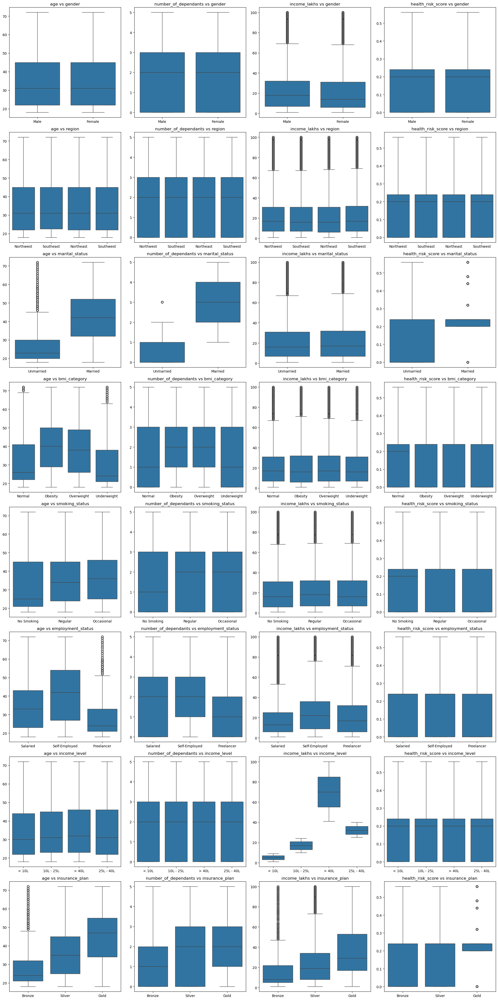

In [76]:
import math

total_plots = len(cat_features) * len(num_features)
cols = 4
rows = math.ceil(total_plots / cols)

# Create subplots grid
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
axes = axes.flatten()  # flatten for easy indexing

plot_index = 0
for cat_col in cat_features:
    for num_col in num_features:
        ax = axes[plot_index]
        sns.boxplot(
            data=df,
            x=cat_col,
            y=num_col,
            #hue='default',
            ax=ax
        )
        ax.set_title(f"{num_col} vs {cat_col}")
        ax.set_xlabel('')
        ax.set_ylabel('')
        plot_index += 1

# Remove any empty subplots (if total_plots < rows*cols)
for i in range(plot_index, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

##### `Multi-Variate (with Target)`

<Axes: xlabel='income_lakhs', ylabel='annual_premium_amount'>

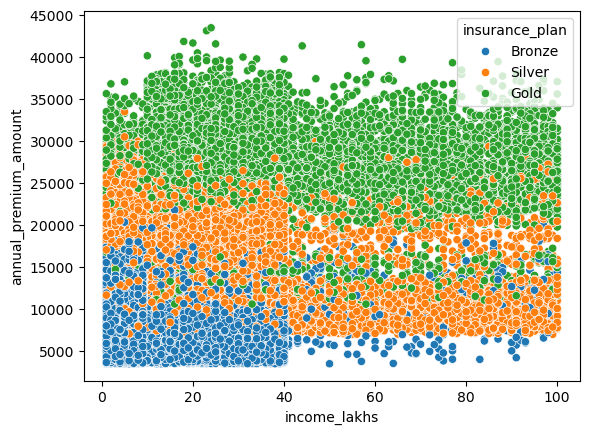

In [77]:
sns.scatterplot(x=df['income_lakhs'], y=df['annual_premium_amount'], hue=df['insurance_plan'])

<Axes: xlabel='income_lakhs', ylabel='annual_premium_amount'>

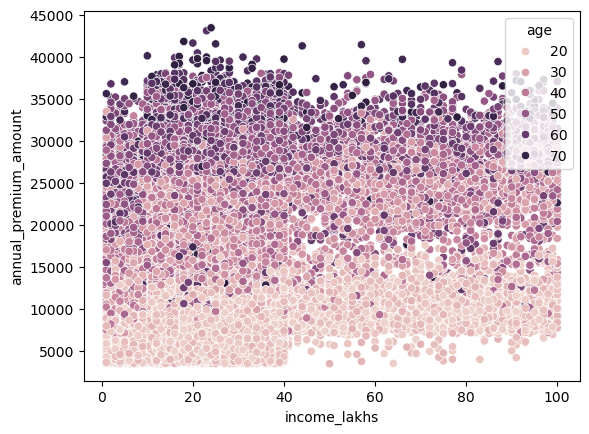

In [78]:
sns.scatterplot(x=df['income_lakhs'], y=df['annual_premium_amount'], hue=df['age'])

<Axes: xlabel='age', ylabel='annual_premium_amount'>

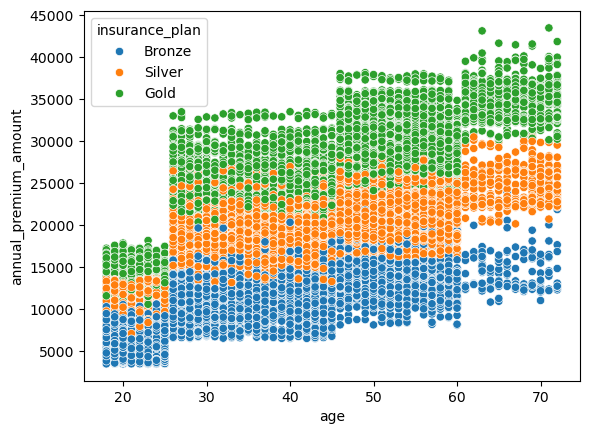

In [79]:
sns.scatterplot(x=df['age'], y=df['annual_premium_amount'], hue=df['insurance_plan'])

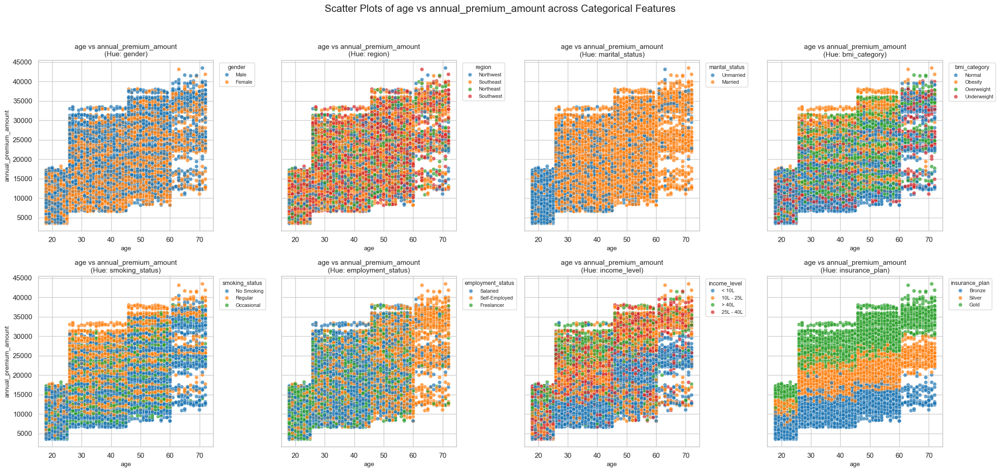

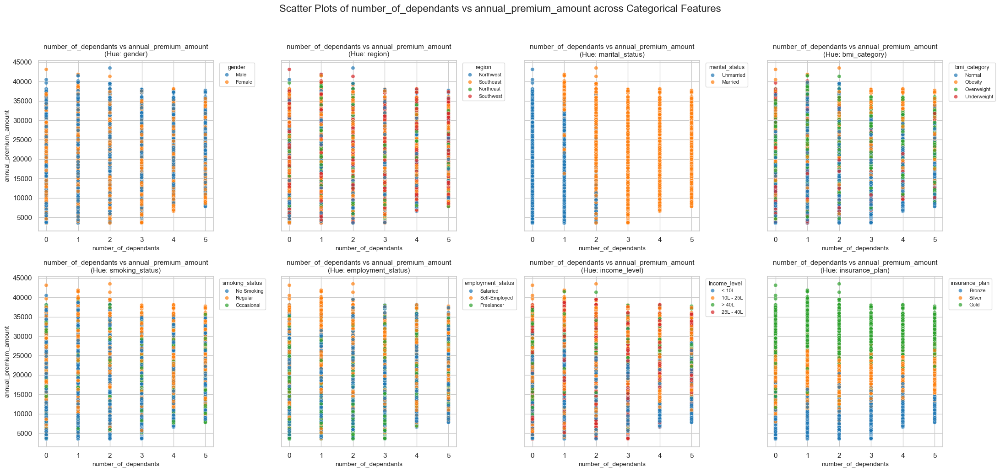

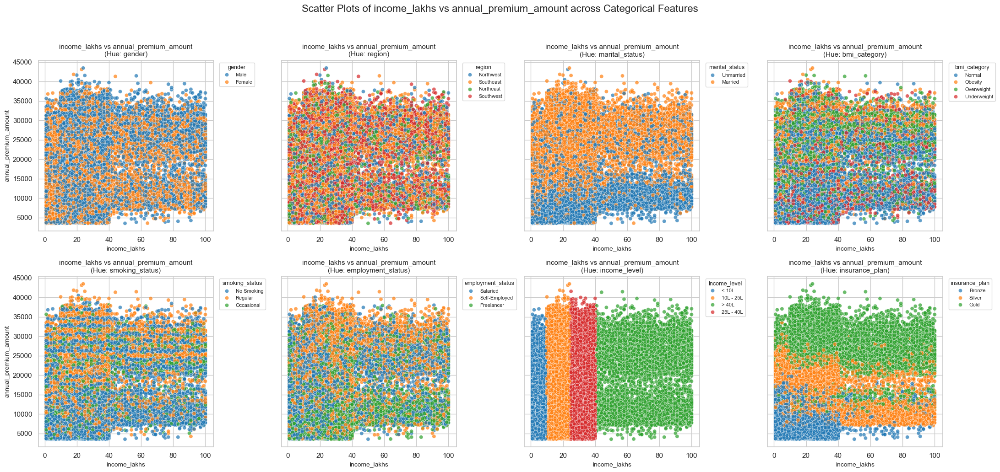

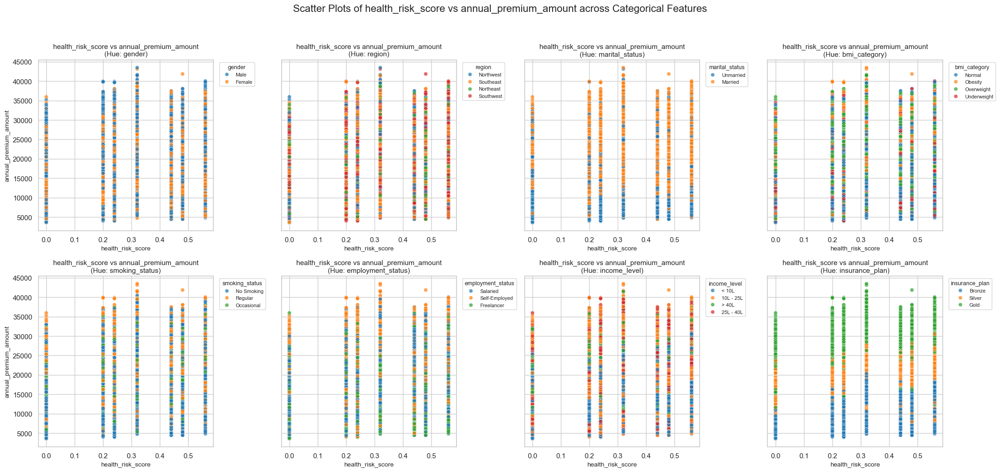

In [80]:

# Set overall plot styling
sns.set_theme(style='whitegrid')

# Loop through each numerical feature
for num_feat in num_features:
  # Create a figure with 2 rows and 4 columns (4 columns total)
  fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(22, 10), sharey=True)
  axes = axes.flatten()  # Flatten to easily iterate through axes

  # Loop through each categorical feature and plot on its respective subplot
  for i, cat_feat in enumerate(cat_features):
    sns.scatterplot(
        data=df,
        x=num_feat,
        y='annual_premium_amount',
        hue=cat_feat,
        ax=axes[i],
        alpha=0.7,
        palette='tab10',
    )

    axes[i].set_title(f'{num_feat} vs annual_premium_amount\n(Hue: {cat_feat})', fontsize=11)
    axes[i].set_xlabel(num_feat, fontsize=10)
    axes[i].set_ylabel('annual_premium_amount', fontsize=10)

    # Clean up legends to prevent clutter
    axes[i].legend(
        title=cat_feat,
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        fontsize=8,
        title_fontsize=9,
    )

  # Adjust layout so subplots and legends don't overlap
  plt.suptitle(
      f'Scatter Plots of {num_feat} vs annual_premium_amount across Categorical Features',
      fontsize=16,
      y=1.03,
  )
  plt.tight_layout()
  plt.show()

#### __`Train-Test Split`__

In [81]:
checkpoint_df = df.copy()

In [82]:
df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,health_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,< 10L,6,Bronze,9053,0.24
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,< 10L,6,Bronze,16339,0.24
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,Silver,18164,0.24
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,Gold,20303,0.00
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,Silver,13365,0.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49903,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,Bronze,9111,0.00
49904,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Gold,27076,0.20
49905,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,Bronze,8564,0.00
49906,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,Bronze,9490,0.00


In [83]:
X, y = df.drop(columns=['annual_premium_amount']), df['annual_premium_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [84]:
X_train

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,health_risk_score
36327,38,Male,Southwest,Married,3,Obesity,Regular,Salaried,10L - 25L,10,Silver,0.32
45474,31,Male,Southwest,Married,4,Underweight,No Smoking,Salaried,> 40L,45,Gold,0.56
23623,44,Male,Southeast,Unmarried,0,Normal,No Smoking,Self-Employed,< 10L,6,Bronze,0.32
10397,44,Male,Southeast,Unmarried,0,Normal,Regular,Salaried,< 10L,4,Bronze,0.24
46139,48,Male,Northeast,Unmarried,0,Normal,Occasional,Salaried,> 40L,56,Bronze,0.24
...,...,...,...,...,...,...,...,...,...,...,...,...
11284,22,Female,Southeast,Married,3,Normal,No Smoking,Salaried,< 10L,2,Bronze,0.24
44732,25,Male,Northwest,Unmarried,1,Underweight,No Smoking,Freelancer,25L - 40L,32,Bronze,0.00
38158,46,Male,Northeast,Married,3,Overweight,Regular,Self-Employed,10L - 25L,21,Gold,0.24
860,55,Female,Southeast,Married,2,Obesity,Occasional,Salaried,< 10L,9,Silver,0.24


In [85]:
X_test

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,health_risk_score
24046,37,Female,Northwest,Married,3,Normal,No Smoking,Salaried,< 10L,2,Bronze,0.24
199,25,Female,Northwest,Unmarried,1,Normal,No Smoking,Freelancer,> 40L,64,Gold,0.00
25415,22,Male,Northwest,Unmarried,0,Overweight,Regular,Salaried,< 10L,2,Bronze,0.00
32436,26,Male,Southwest,Married,2,Normal,No Smoking,Salaried,10L - 25L,21,Gold,0.32
30769,30,Female,Southwest,Unmarried,1,Normal,No Smoking,Self-Employed,< 10L,9,Bronze,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...
12098,32,Female,Southwest,Married,3,Underweight,No Smoking,Salaried,< 10L,3,Bronze,0.20
31827,28,Female,Southeast,Married,3,Normal,Occasional,Self-Employed,25L - 40L,39,Silver,0.00
6698,44,Female,Southeast,Married,3,Underweight,Occasional,Salaried,10L - 25L,24,Silver,0.24
16918,55,Male,Southwest,Unmarried,1,Overweight,Regular,Salaried,< 10L,3,Silver,0.48


In [86]:
y_train

36327    26193
45474    26476
23623    12624
10397    12386
46139    11614
         ...  
11284     5507
44732     8953
38158    32037
860      23328
15795    27210
Name: annual_premium_amount, Length: 34935, dtype: int64

In [87]:
y_test

24046     9246
199      11664
25415    10472
32436    26267
30769     9106
         ...  
12098     9529
31827    14240
6698     16992
16918    25620
15081    12437
Name: annual_premium_amount, Length: 14973, dtype: int64

#### __`Feature Transformation : Encoding, Scaling`__

In [88]:
print(num_features)
print(cat_features)

['age', 'number_of_dependants', 'income_lakhs', 'health_risk_score']
['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'insurance_plan']


In [89]:
# -------------------------------------------------------------------------------------------------------------------
# ENCODING
#   One Hot Encoding  :   'gender', 'region', 'marital_status', 'employment_status'
#   Ordinal Encoding  :   'bmi_category', 'smoking_status', 'income_level', 'insurance_plan'
# -------------------------------------------------------------------------------------------------------------------
# SCALING
#   No Scaling      :   OHE features ['gender', 'region', 'marital_status', 'employment_status']
#                   :   'health_risk_score' is already normalised
#   StandardScaler  :   Ordinal Encoded Features ['bmi_category', 'smoking_status', 'income_level', 'insurance_plan']
#                   :   ( num_features - ['health_risk_score'] ), i.e., ['age', 'number_of_dependants', 'income_lakhs']
# -------------------------------------------------------------------------------------------------------------------

In [90]:
nominal_features = ['gender', 'region', 'marital_status', 'employment_status']
ordinal_features = ['bmi_category', 'smoking_status', 'income_level', 'insurance_plan']

In [91]:
for feature in ordinal_features:
    print(df[feature].unique())

['Normal' 'Obesity' 'Overweight' 'Underweight']
['No Smoking' 'Regular' 'Occasional']
['< 10L' '10L - 25L' '> 40L' '25L - 40L']
['Bronze' 'Silver' 'Gold']


In [92]:
ordinal_categories = [
    ['Underweight', 'Normal', 'Overweight', 'Obesity'],
    ['No Smoking', 'Occasional', 'Regular'],
    ['< 10L', '10L - 25L', '25L - 40L', '> 40L'],
    ['Bronze', 'Silver', 'Gold']
]

In [93]:
feature_engg = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(drop='first'), nominal_features),
    ('numerical', StandardScaler(), num_features),
    ('ordinal', Pipeline(steps=[
        ('encode', OrdinalEncoder(categories=ordinal_categories)),
        ('scale', StandardScaler())]), ordinal_features)   
], remainder='passthrough', verbose_feature_names_out=False)        

#   remainder='passthrough' is very important
#   verbose_feature_names_out=False removes ugly prefixes

In [94]:
X_train_transformed = pd.DataFrame(feature_engg.fit_transform(X_train), columns=feature_engg.get_feature_names_out())

In [95]:
X_train_transformed

,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,employment_status_Salaried,employment_status_Self-Employed,age,number_of_dependants,income_lakhs,health_risk_score,bmi_category,smoking_status,income_level,insurance_plan
0,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.26,0.86,-0.58,0.98,1.81,1.37,-0.11,0.26
1,1.00,0.00,0.00,1.00,0.00,1.00,0.00,-0.25,1.53,1.00,2.47,-1.50,-0.85,1.80,1.54
2,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.70,-1.15,-0.76,0.98,-0.39,-0.85,-1.06,-1.01
3,1.00,0.00,1.00,0.00,1.00,1.00,0.00,0.70,-1.15,-0.85,0.48,-0.39,1.37,-1.06,-1.01
4,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.99,-1.15,1.50,0.48,-0.39,0.26,1.80,-1.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34930,0.00,0.00,1.00,0.00,0.00,1.00,0.00,-0.91,0.86,-0.94,0.48,-0.39,-0.85,-1.06,-1.01
34931,1.00,1.00,0.00,0.00,1.00,0.00,0.00,-0.69,-0.48,0.42,-1.01,-1.50,-0.85,0.84,-1.01
34932,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.85,0.86,-0.08,0.48,0.71,1.37,-0.11,1.54
34933,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.50,0.19,-0.63,0.48,1.81,0.26,-1.06,0.26


In [96]:
X_train_transformed.describe()

,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,employment_status_Salaried,employment_status_Self-Employed,age,number_of_dependants,income_lakhs,health_risk_score,bmi_category,smoking_status,income_level,insurance_plan
count,34935.00,34935.00,34935.00,34935.00,34935.00,34935.00,34935.00,34935.00,34935.00,34935.00,34935.00,34935.00,34935.00,34935.00,34935.00
mean,0.55,0.20,0.35,0.30,0.51,0.42,0.27,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00
std,0.50,0.40,0.48,0.46,0.50,0.49,0.44,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.20,-1.15,-0.99,-1.01,-1.50,-0.85,-1.06,-1.01
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.91,-1.15,-0.72,-1.01,-0.39,-0.85,-1.06,-1.01
50%,1.00,0.00,0.00,0.00,1.00,0.00,0.00,-0.25,0.19,-0.31,0.23,-0.39,-0.85,-0.11,0.26
75%,1.00,0.00,1.00,1.00,1.00,1.00,1.00,0.77,0.86,0.37,0.48,0.71,1.37,0.84,0.26
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.74,2.20,3.50,2.47,1.81,1.37,1.80,1.54


#### __`Feature Selection`__

In [97]:
# Do VIF here (after scaling encoding etc are done)

In [98]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    X_const = sm.add_constant(data)     # 'const' column added to the input dataframe (for intercept)
    
    vif_df = pd.DataFrame()
    vif_df['Column'] = X_const.columns
    vif_df['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

    vif_df = vif_df[vif_df['Column']!='const'].reset_index(drop=True)   # dropping VIF for the constant term because it's meaningless
    
    return vif_df

In [99]:
calculate_vif(X_train_transformed)

,Column,VIF
0,gender_Male,1.10
1,region_Northwest,1.90
2,region_Southeast,2.21
3,region_Southwest,2.15
4,marital_status_Unmarried,4.15
5,employment_status_Salaried,1.45
6,employment_status_Self-Employed,1.59
7,age,2.03
8,number_of_dependants,3.50
9,income_lakhs,5.52


In [ ]:
# income_lakhs and income_level have VIF>5
# This is expected because they're essentially the same feature

In [103]:
calculate_vif(X_train_transformed.drop(columns=['income_level']))

,Column,VIF
0,gender_Male,1.10
1,region_Northwest,1.90
2,region_Southeast,2.21
3,region_Southwest,2.15
4,marital_status_Unmarried,4.15
5,employment_status_Salaried,1.45
6,employment_status_Self-Employed,1.59
7,age,2.02
8,number_of_dependants,3.50
9,income_lakhs,1.28


- I'll drop income_level because it's essentially the same data as income_lakhs

In [ ]:
#X_train_transformed.corr()

,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,employment_status_Salaried,employment_status_Self-Employed,age,number_of_dependants,income_lakhs,health_risk_score,bmi_category,smoking_status,income_level,insurance_plan
gender_Male,1.00,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.04,-0.00,0.04,0.29,0.06,0.03
region_Northwest,-0.00,1.00,-0.37,-0.33,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00
region_Southeast,-0.00,-0.37,1.00,-0.48,-0.01,-0.01,0.00,0.00,0.01,-0.00,0.00,0.01,0.00,-0.00,0.00
region_Southwest,0.00,-0.33,-0.48,1.00,0.01,0.00,-0.01,-0.01,-0.00,0.01,-0.00,-0.00,-0.00,0.01,-0.01
marital_status_Unmarried,0.00,-0.00,-0.01,0.01,1.00,-0.06,-0.17,-0.54,-0.84,-0.01,-0.43,-0.18,-0.12,-0.01,-0.32
employment_status_Salaried,0.00,-0.00,-0.01,0.00,-0.06,1.00,-0.52,-0.01,0.07,-0.10,0.06,0.04,0.05,-0.13,-0.04
employment_status_Self-Employed,0.00,0.00,0.00,-0.01,-0.17,-0.52,1.00,0.31,0.11,0.11,0.14,0.06,0.00,0.14,0.22
age,-0.00,0.00,0.00,-0.01,-0.54,-0.01,0.31,1.00,0.42,0.03,0.44,0.23,0.08,0.03,0.50
number_of_dependants,-0.00,0.00,0.01,-0.00,-0.84,0.07,0.11,0.42,1.00,0.01,0.37,0.18,0.13,0.01,0.26
income_lakhs,0.04,-0.00,-0.00,0.01,-0.01,-0.10,0.11,0.03,0.01,1.00,0.02,0.01,0.01,0.90,0.41


#### __`Data Pre-Processing Pipeline`__

In [105]:
num_features = ['age', 'number_of_dependants', 'income_lakhs', 'health_risk_score']
cat_features = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'insurance_plan']

nominal_features = ['gender', 'region', 'marital_status', 'employment_status']
ordinal_features = ['bmi_category', 'smoking_status', 'insurance_plan']

ordinal_categories = [
    ['Underweight', 'Normal', 'Overweight', 'Obesity'],
    ['No Smoking', 'Occasional', 'Regular'],
    ['Bronze', 'Silver', 'Gold']
]

In [106]:
preprocessor = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(drop='first'), nominal_features),
    ('numerical', StandardScaler(), num_features),
    ('ordinal', Pipeline(steps=[
        ('encode', OrdinalEncoder(categories=ordinal_categories)),
        ('scale', StandardScaler())]), ordinal_features)   
    ],
    remainder='drop',
    verbose_feature_names_out=False)

In [ ]:
#pd.DataFrame(preprocessor.fit_transform(X_train), columns=preprocessor.get_feature_names_out())

,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,employment_status_Salaried,employment_status_Self-Employed,age,number_of_dependants,income_lakhs,health_risk_score,bmi_category,smoking_status,insurance_plan
0,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.26,0.86,-0.58,0.98,1.81,1.37,0.26
1,1.00,0.00,0.00,1.00,0.00,1.00,0.00,-0.25,1.53,1.00,2.47,-1.50,-0.85,1.54
2,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.70,-1.15,-0.76,0.98,-0.39,-0.85,-1.01
3,1.00,0.00,1.00,0.00,1.00,1.00,0.00,0.70,-1.15,-0.85,0.48,-0.39,1.37,-1.01
4,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.99,-1.15,1.50,0.48,-0.39,0.26,-1.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34930,0.00,0.00,1.00,0.00,0.00,1.00,0.00,-0.91,0.86,-0.94,0.48,-0.39,-0.85,-1.01
34931,1.00,1.00,0.00,0.00,1.00,0.00,0.00,-0.69,-0.48,0.42,-1.01,-1.50,-0.85,-1.01
34932,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.85,0.86,-0.08,0.48,0.71,1.37,1.54
34933,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.50,0.19,-0.63,0.48,1.81,0.26,0.26


#### __`Model Training & Evaluation`__

In [123]:
def evaluate_model(model_name, X_train, X_test, y_train, y_test):
    
    # Train set Evaluation
    y_pred_train = model_name.predict(X_train)

    print('PERFORMANCE WITH TRAIN SET\n---------------------------')
    print(f"MAE        :  {mean_absolute_error(y_train, y_pred_train):,.2f}")
    print(f"MSE        :  {mean_squared_error(y_train, y_pred_train):,.2f}")
    print(f"RMSE       :  {np.sqrt(mean_squared_error(y_train, y_pred_train)):,.2f}")
    print(f"R2 Score   :  {r2_score(y_train, y_pred_train):.4f}")

    # Test set Evaluation
    y_pred_test = model_name.predict(X_test)

    print('\n\nPERFORMANCE WITH TEST SET\n---------------------------')
    print(f"MAE        :  {mean_absolute_error(y_test, y_pred_test):,.2f}")
    print(f"MSE        :  {mean_squared_error(y_test, y_pred_test):,.2f}")
    print(f"RMSE       :  {np.sqrt(mean_squared_error(y_test, y_pred_test)):,.2f}")
    print(f"R2 Score   :  {r2_score(y_test, y_pred_test):.4f}")

---

##### Model 1 : Linear Regression

In [ ]:
model_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('linear_regressor', LinearRegression())
])

model_1.fit(X_train, y_train)
evaluate_model(model_1, X_train, X_test, y_train, y_test)

PERFORMANCE WITH TRAIN SET
---------------------------
MAE        :  1,815.51
MSE        :  5,445,328.81
RMSE       :  2,333.52
R2 Score   :  0.9233


PERFORMANCE WITH TEST SET
---------------------------
MAE        :  1,800.19
MSE        :  5,370,415.24
RMSE       :  2,317.42
R2 Score   :  0.9239


In [153]:
print('COEFFICIENTS : \n------------------------------------------')
print(pd.Series(model_1.named_steps['linear_regressor'].coef_, index=model_1.named_steps['preprocessor'].get_feature_names_out()).sort_values(ascending=False))

COEFFICIENTS : 
------------------------------------------
insurance_plan                    4921.24
age                               2866.93
health_risk_score                 1383.21
bmi_category                      1028.76
smoking_status                    1001.59
employment_status_Self-Employed    382.43
employment_status_Salaried         149.45
gender_Male                        110.04
region_Southeast                    38.86
region_Southwest                   -23.82
region_Northwest                   -35.27
income_lakhs                       -82.11
number_of_dependants              -166.71
marital_status_Unmarried          -840.88
dtype: float64


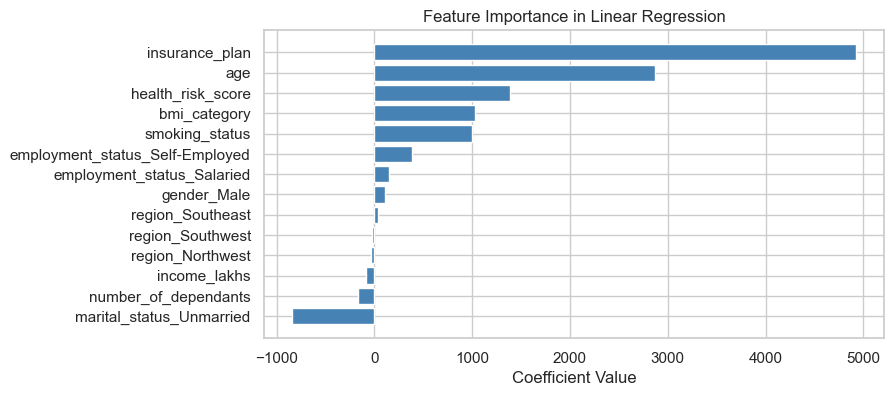

In [ ]:
coef_df = pd.DataFrame(
    model_1.named_steps['linear_regressor'].coef_,
    index=model_1.named_steps['preprocessor'].get_feature_names_out(),
    columns=['coefficients']
    ).sort_values(by='coefficients', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.gca().invert_yaxis()
plt.show()

---

##### Model 2 : XGB

In [136]:
model_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb_regressor', XGBRegressor())
])

model_2.fit(X_train, y_train)
evaluate_model(model_2, X_train, X_test, y_train, y_test)

PERFORMANCE WITH TRAIN SET
---------------------------
MAE        :  667.40
MSE        :  988,906.46
RMSE       :  994.44
R2 Score   :  0.9861


PERFORMANCE WITH TEST SET
---------------------------
MAE        :  780.04
MSE        :  1,369,769.55
RMSE       :  1,170.37
R2 Score   :  0.9806


In [155]:
print('FEATURE IMPORTANCE : \n------------------------------------------')
print(pd.Series(model_2.named_steps['xgb_regressor'].feature_importances_, index=model_2.named_steps['preprocessor'].get_feature_names_out()).sort_values(ascending=False))

FEATURE IMPORTANCE : 
------------------------------------------
insurance_plan                    0.64
age                               0.28
health_risk_score                 0.03
smoking_status                    0.03
bmi_category                      0.02
number_of_dependants              0.00
employment_status_Self-Employed   0.00
region_Southwest                  0.00
marital_status_Unmarried          0.00
income_lakhs                      0.00
employment_status_Salaried        0.00
region_Northwest                  0.00
region_Southeast                  0.00
gender_Male                       0.00
dtype: float32


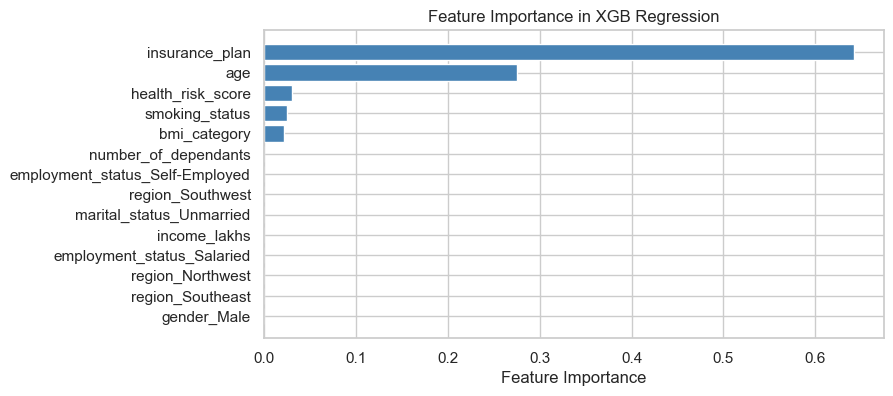

In [158]:
feature_importance_df = pd.DataFrame(
    model_2.named_steps['xgb_regressor'].feature_importances_,
    index=model_2.named_steps['preprocessor'].get_feature_names_out(),
    columns=['feature_importance']
    ).sort_values(by='feature_importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(feature_importance_df.index, feature_importance_df['feature_importance'], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance in XGB Regression')
plt.gca().invert_yaxis()
plt.show()

---

##### Model 3 : Random Forest

In [160]:
model_3 = Pipeline([
    ('preprocessor', preprocessor),
    ('rf_regressor', RandomForestRegressor())
])

model_3.fit(X_train, y_train)
evaluate_model(model_3, X_train, X_test, y_train, y_test)

PERFORMANCE WITH TRAIN SET
---------------------------
MAE        :  310.80
MSE        :  243,551.33
RMSE       :  493.51
R2 Score   :  0.9966


PERFORMANCE WITH TEST SET
---------------------------
MAE        :  803.62
MSE        :  1,479,214.48
RMSE       :  1,216.23
R2 Score   :  0.9790


In [163]:
print('FEATURE IMPORTANCE : \n------------------------------------------')
print(pd.Series(model_3.named_steps['rf_regressor'].feature_importances_, index=model_3.named_steps['preprocessor'].get_feature_names_out()).sort_values(ascending=False))

FEATURE IMPORTANCE : 
------------------------------------------
age                               0.59
insurance_plan                    0.34
health_risk_score                 0.02
bmi_category                      0.02
smoking_status                    0.02
income_lakhs                      0.01
number_of_dependants              0.00
employment_status_Salaried        0.00
gender_Male                       0.00
region_Southeast                  0.00
region_Southwest                  0.00
region_Northwest                  0.00
employment_status_Self-Employed   0.00
marital_status_Unmarried          0.00
dtype: float64


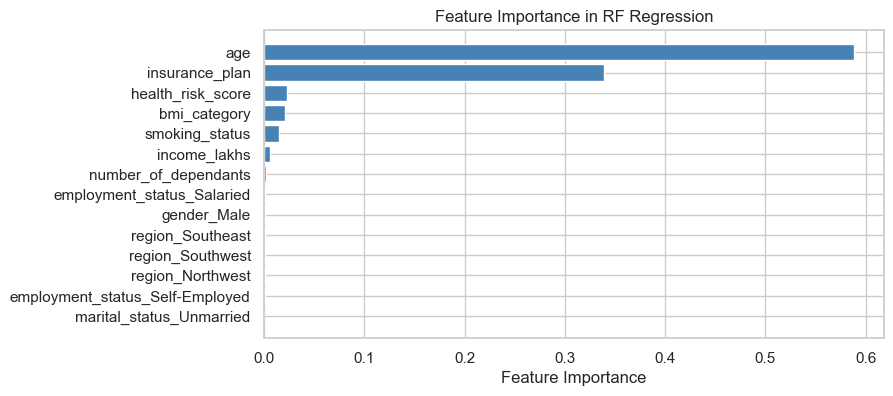

In [164]:
feature_importance_df = pd.DataFrame(
    model_3.named_steps['rf_regressor'].feature_importances_,
    index=model_3.named_steps['preprocessor'].get_feature_names_out(),
    columns=['feature_importance']
    ).sort_values(by='feature_importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(feature_importance_df.index, feature_importance_df['feature_importance'], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance in RF Regression')
plt.gca().invert_yaxis()
plt.show()

---

##### Model 4 : Decision Tree

In [165]:
model_4 = Pipeline([
    ('preprocessor', preprocessor),
    ('dt_regressor', DecisionTreeRegressor())
])

model_4.fit(X_train, y_train)
evaluate_model(model_4, X_train, X_test, y_train, y_test)

PERFORMANCE WITH TRAIN SET
---------------------------
MAE        :  36.38
MSE        :  58,094.44
RMSE       :  241.03
R2 Score   :  0.9992


PERFORMANCE WITH TEST SET
---------------------------
MAE        :  1,038.27
MSE        :  2,657,968.79
RMSE       :  1,630.33
R2 Score   :  0.9624


In [167]:
print('FEATURE IMPORTANCE : \n------------------------------------------')
print(pd.Series(model_4.named_steps['dt_regressor'].feature_importances_, index=model_4.named_steps['preprocessor'].get_feature_names_out()).sort_values(ascending=False))

FEATURE IMPORTANCE : 
------------------------------------------
age                               0.59
insurance_plan                    0.34
health_risk_score                 0.02
bmi_category                      0.02
smoking_status                    0.02
income_lakhs                      0.01
number_of_dependants              0.00
employment_status_Salaried        0.00
region_Southeast                  0.00
region_Southwest                  0.00
employment_status_Self-Employed   0.00
gender_Male                       0.00
region_Northwest                  0.00
marital_status_Unmarried          0.00
dtype: float64


---

In [ ]:
# Below cells were just trying out stuff

#dir(model_3)
#dir(model_3.named_steps['rf_regressor'])
#model_3.named_steps['rf_regressor'].feature_importances_

##### Performing Hyper-Parameter Tuning for the selected model

In [169]:
param_distributions = {
    'xgb_regressor__n_estimators': [100, 200, 500, 1000],
    'xgb_regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb_regressor__max_depth': [3, 4, 5, 6, 8],
    'xgb_regressor__subsample': [0.6, 0.8, 1.0],
    'xgb_regressor__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb_regressor__min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=model_2,
    param_distributions=param_distributions,
    n_iter=30,          # Number of parameter settings sampled
    cv=5,               # 5-fold cross-validation
    scoring='r2',       
    random_state=42,
    n_jobs=-1,          
    verbose=1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

evaluate_model(best_model, X_train, X_test, y_train, y_test)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
PERFORMANCE WITH TRAIN SET
---------------------------
MAE        :  763.06
MSE        :  1,259,121.10
RMSE       :  1,122.11
R2 Score   :  0.9823


PERFORMANCE WITH TEST SET
---------------------------
MAE        :  768.81
MSE        :  1,279,021.14
RMSE       :  1,130.94
R2 Score   :  0.9819


In [172]:
random_search.best_params_

{'xgb_regressor__subsample': 0.8,
 'xgb_regressor__n_estimators': 200,
 'xgb_regressor__min_child_weight': 3,
 'xgb_regressor__max_depth': 4,
 'xgb_regressor__learning_rate': 0.05,
 'xgb_regressor__colsample_bytree': 1.0}

In [ ]:
#best_model.named_steps['xgb_regressor'].feature_importances_

array([3.8825141e-04, 4.2430990e-04, 1.8983521e-04, 3.4323923e-04,
       2.2941842e-04, 2.7625790e-04, 3.3388680e-04, 4.4419855e-01,
       3.0291185e-04, 2.7249812e-04, 2.4535445e-02, 2.6118742e-02,
       2.2076137e-02, 4.8031062e-01], dtype=float32)

In [ ]:
#random_search.best_estimator_.named_steps['xgb_regressor'].feature_importances_

array([3.8825141e-04, 4.2430990e-04, 1.8983521e-04, 3.4323923e-04,
       2.2941842e-04, 2.7625790e-04, 3.3388680e-04, 4.4419855e-01,
       3.0291185e-04, 2.7249812e-04, 2.4535445e-02, 2.6118742e-02,
       2.2076137e-02, 4.8031062e-01], dtype=float32)

In [ ]:
#evaluate_model(random_search, X_train, X_test, y_train, y_test)

PERFORMANCE WITH TRAIN SET
---------------------------
MAE        :  763.06
MSE        :  1,259,121.10
RMSE       :  1,122.11
R2 Score   :  0.9823


PERFORMANCE WITH TEST SET
---------------------------
MAE        :  768.81
MSE        :  1,279,021.14
RMSE       :  1,130.94
R2 Score   :  0.9819


In [ ]:
#best_model.get_params

<bound method Pipeline.get_params of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'region',
                                                   'marital_status',
                                                   'employment_status']),
                                                 ('numerical', StandardScaler(),
                                                  ['age',
                                                   'number_of_dependants',
                                                   'income_lakhs',
                                                   'health_risk_score']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('encode',
                                                                   OrdinalEncoder(c

#### __`Error Analysis`__

##### ResultsDF and Extreme Errors

In [222]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residual_pct = (residuals/y_test)*100

In [203]:
# results_df = pd.DataFrame()
# results_df['actual'] = y_test
# results_df['predicted'] = y_pred
# results_df['difference'] = residuals
# results_df['difference_percent'] = residual_pct
# results_df

,actual,predicted,difference,difference_percent
24046,9246,9252.82,6.82,0.07
199,11664,13415.32,1751.32,15.01
25415,10472,7354.12,-3117.88,-29.77
32436,26267,25767.96,-499.04,-1.90
30769,9106,9250.44,144.44,1.59
...,...,...,...,...
12098,9529,9504.26,-24.74,-0.26
31827,14240,15031.16,791.16,5.56
6698,16992,17086.33,94.33,0.56
16918,25620,25389.77,-230.23,-0.90


In [223]:
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residual_pct
})

results_df = results_df.sort_values(by='diff_pct')
results_df

,actual,predicted,diff,diff_pct
2232,9686,6591.99,-3094.01,-31.94
32950,9468,6462.09,-3005.91,-31.75
10050,9483,6481.30,-3001.70,-31.65
26581,9494,6494.42,-2999.58,-31.59
48731,9414,6447.89,-2966.11,-31.51
...,...,...,...,...
23923,3520,6554.17,3034.17,86.20
29843,3503,6532.75,3029.75,86.49
29386,3546,6622.09,3076.09,86.75
25151,3501,6541.59,3040.59,86.85


<Axes: xlabel='diff_pct', ylabel='Count'>

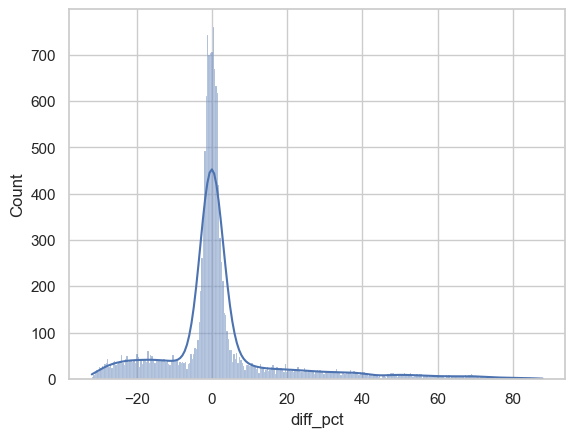

In [224]:
sns.histplot(results_df['diff_pct'], kde=True)

In [225]:
ERROR_THRESHOLD = 10

In [226]:
extreme_results_df = results_df[np.abs(results_df['diff_pct'])>ERROR_THRESHOLD]
extreme_results_df

,actual,predicted,diff,diff_pct
2232,9686,6591.99,-3094.01,-31.94
32950,9468,6462.09,-3005.91,-31.75
10050,9483,6481.30,-3001.70,-31.65
26581,9494,6494.42,-2999.58,-31.59
48731,9414,6447.89,-2966.11,-31.51
...,...,...,...,...
23923,3520,6554.17,3034.17,86.20
29843,3503,6532.75,3029.75,86.49
29386,3546,6622.09,3076.09,86.75
25151,3501,6541.59,3040.59,86.85


In [274]:
print('Percent of Predictions with Extreme Errors : ', (extreme_results_df.shape[0]/results_df.shape[0])*100, '%')

Percent of Predictions with Extreme Errors :  29.219261337073398 %


##### Analysing the Errors

In [228]:
X_test.index

Index([24046,   199, 25415, 32436, 30769, 11607, 12789, 33306,  5396, 47848,
       ...
        7730, 25361,  8087, 11102,   677, 12098, 31827,  6698, 16918, 15081],
      dtype='int64', length=14973)

In [229]:
extreme_results_df.index

Index([ 2232, 32950, 10050, 26581, 48731, 46689,  7133,  4330, 29337, 13506,
       ...
       25644, 42707, 37119, 48710, 42260, 23923, 29843, 29386, 25151, 10268],
      dtype='int64', length=4375)

In [232]:
extreme_results_df.index[~extreme_results_df.index.isin(X_test.index)]

Index([], dtype='int64')

In [233]:
X_test

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,health_risk_score
24046,37,Female,Northwest,Married,3,Normal,No Smoking,Salaried,< 10L,2,Bronze,0.24
199,25,Female,Northwest,Unmarried,1,Normal,No Smoking,Freelancer,> 40L,64,Gold,0.00
25415,22,Male,Northwest,Unmarried,0,Overweight,Regular,Salaried,< 10L,2,Bronze,0.00
32436,26,Male,Southwest,Married,2,Normal,No Smoking,Salaried,10L - 25L,21,Gold,0.32
30769,30,Female,Southwest,Unmarried,1,Normal,No Smoking,Self-Employed,< 10L,9,Bronze,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...
12098,32,Female,Southwest,Married,3,Underweight,No Smoking,Salaried,< 10L,3,Bronze,0.20
31827,28,Female,Southeast,Married,3,Normal,Occasional,Self-Employed,25L - 40L,39,Silver,0.00
6698,44,Female,Southeast,Married,3,Underweight,Occasional,Salaried,10L - 25L,24,Silver,0.24
16918,55,Male,Southwest,Unmarried,1,Overweight,Regular,Salaried,< 10L,3,Silver,0.48


In [234]:
y_test

24046     9246
199      11664
25415    10472
32436    26267
30769     9106
         ...  
12098     9529
31827    14240
6698     16992
16918    25620
15081    12437
Name: annual_premium_amount, Length: 14973, dtype: int64

In [ ]:
# errors_df = df.loc[extreme_results_df.index]
# errors_df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,health_risk_score
2232,23,Male,Southeast,Married,3,Normal,Occasional,Freelancer,< 10L,4,Bronze,9686,0.00
32950,25,Male,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,< 10L,7,Bronze,9468,0.00
10050,22,Male,Southwest,Unmarried,1,Normal,No Smoking,Self-Employed,10L - 25L,11,Bronze,9483,0.00
26581,18,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,10L - 25L,16,Bronze,9494,0.00
48731,20,Male,Southeast,Married,3,Normal,No Smoking,Self-Employed,25L - 40L,28,Bronze,9414,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23923,22,Female,Southeast,Unmarried,1,Normal,No Smoking,Salaried,< 10L,2,Bronze,3520,0.00
29843,23,Female,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,25L - 40L,27,Bronze,3503,0.00
29386,19,Female,Southwest,Married,3,Normal,No Smoking,Freelancer,> 40L,64,Bronze,3546,0.00
25151,23,Female,Southwest,Unmarried,1,Normal,No Smoking,Salaried,< 10L,6,Bronze,3501,0.00


In [238]:
errors_df = X_test.loc[extreme_results_df.index]
errors_df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,health_risk_score
2232,23,Male,Southeast,Married,3,Normal,Occasional,Freelancer,< 10L,4,Bronze,0.00
32950,25,Male,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,< 10L,7,Bronze,0.00
10050,22,Male,Southwest,Unmarried,1,Normal,No Smoking,Self-Employed,10L - 25L,11,Bronze,0.00
26581,18,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,10L - 25L,16,Bronze,0.00
48731,20,Male,Southeast,Married,3,Normal,No Smoking,Self-Employed,25L - 40L,28,Bronze,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
23923,22,Female,Southeast,Unmarried,1,Normal,No Smoking,Salaried,< 10L,2,Bronze,0.00
29843,23,Female,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,25L - 40L,27,Bronze,0.00
29386,19,Female,Southwest,Married,3,Normal,No Smoking,Freelancer,> 40L,64,Bronze,0.00
25151,23,Female,Southwest,Unmarried,1,Normal,No Smoking,Salaried,< 10L,6,Bronze,0.00


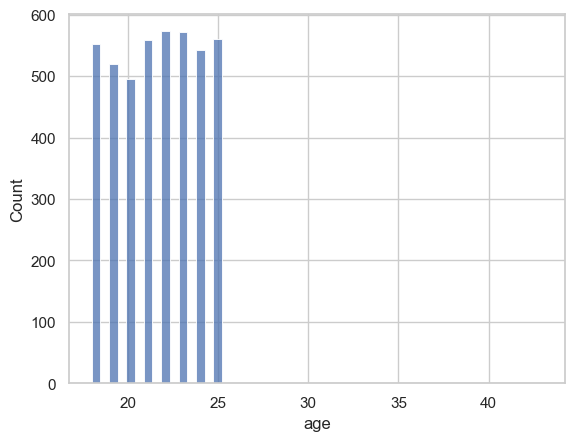

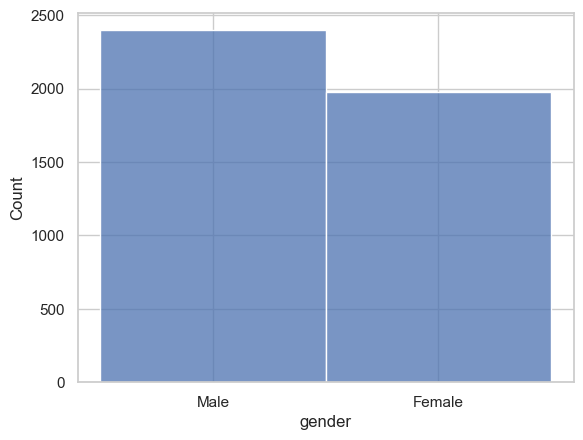

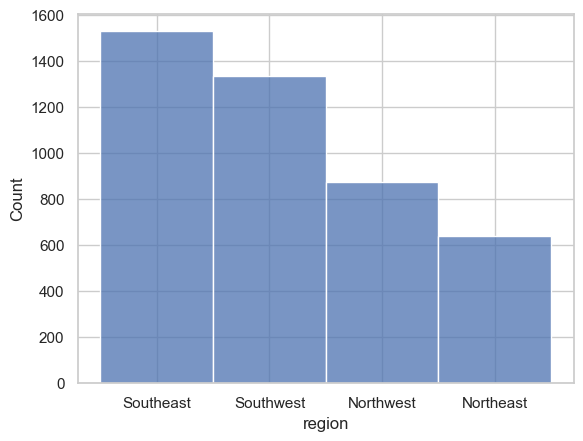

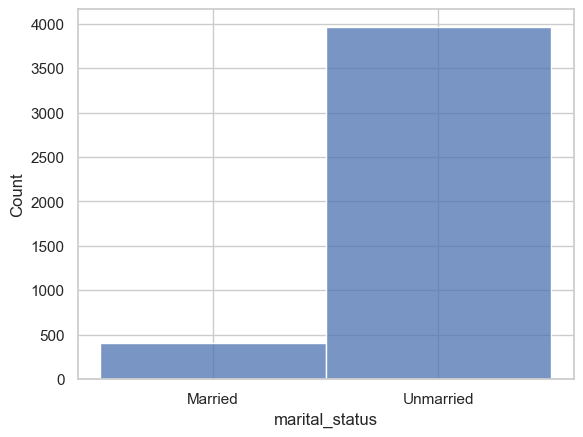

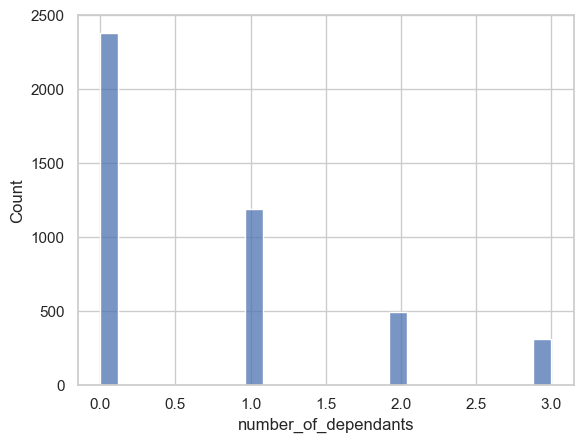

...

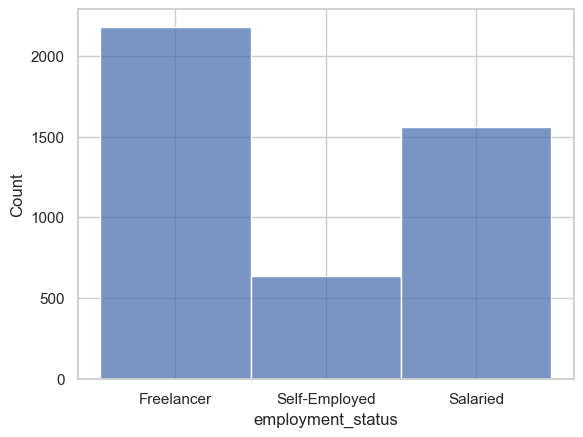

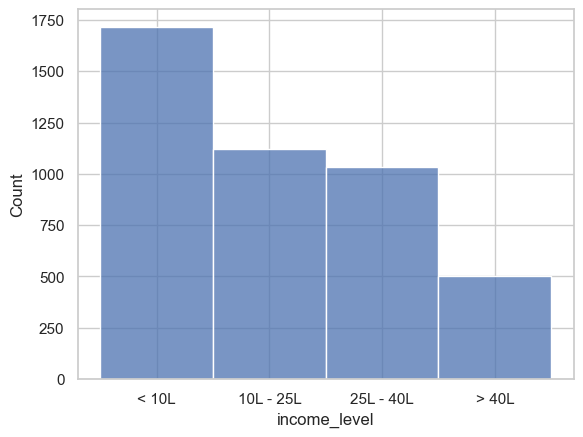

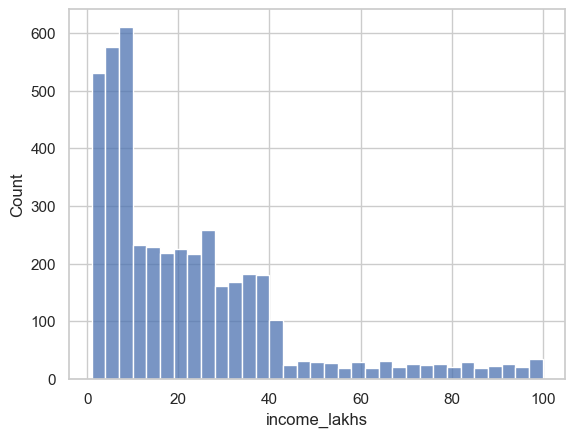

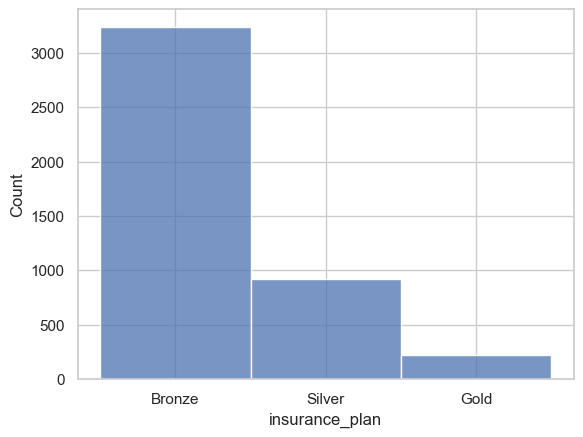

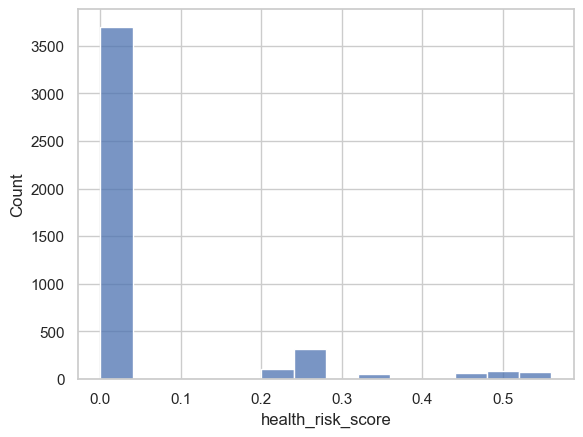

In [258]:
for feature in errors_df.columns:
    sns.histplot(errors_df[feature], label='Overall')
    plt.show()

- `Let's compare distribution of features in Test Set and Extreme Error Set`

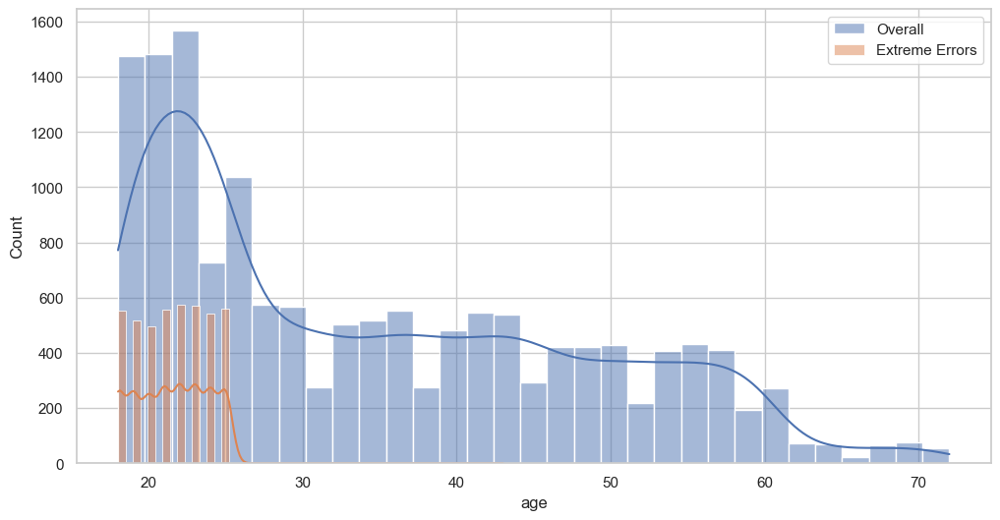

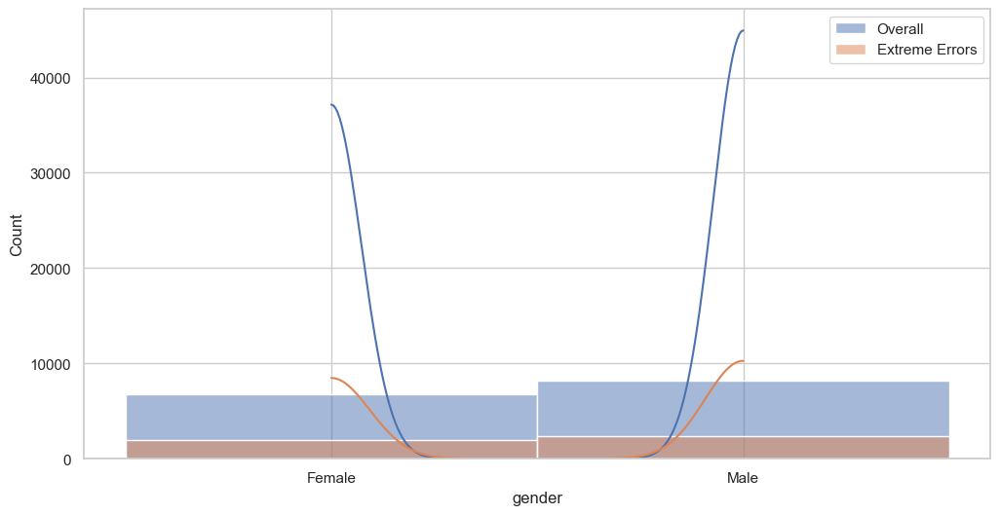

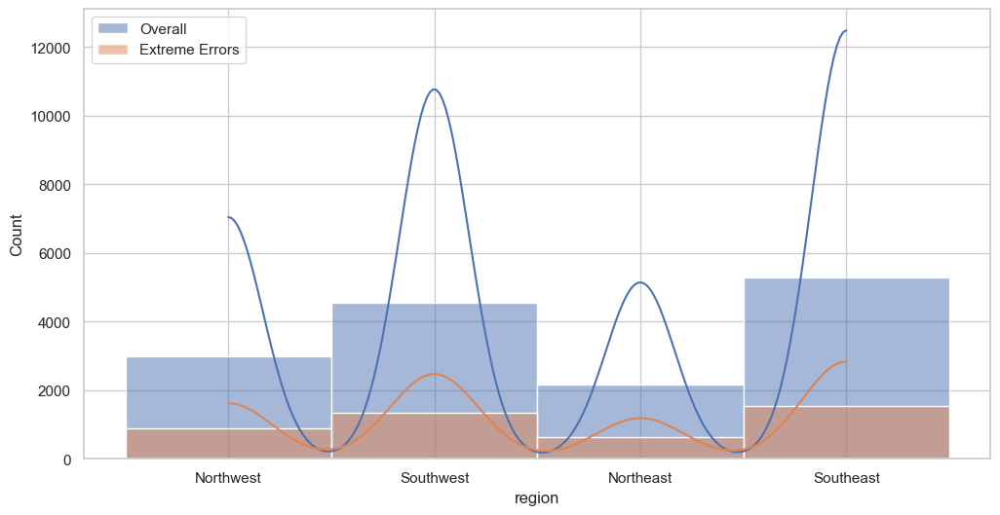

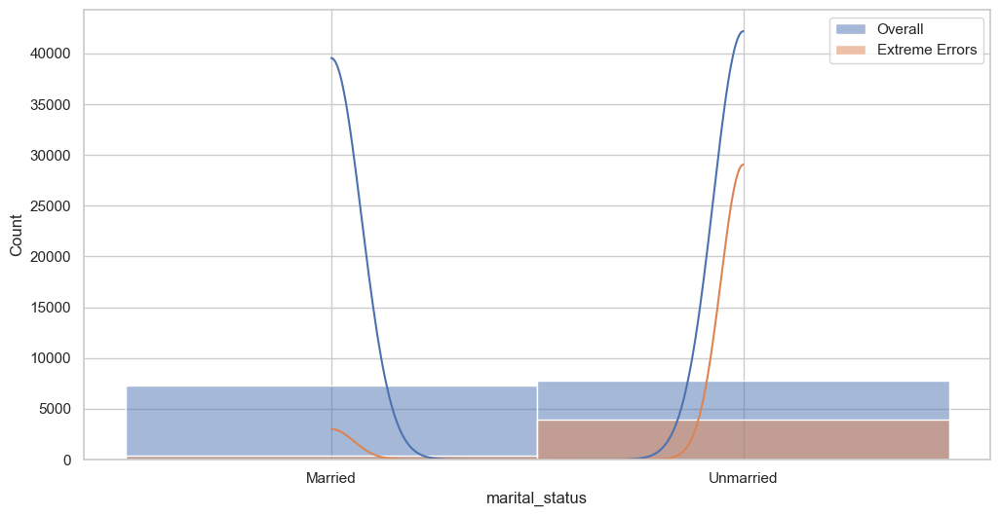

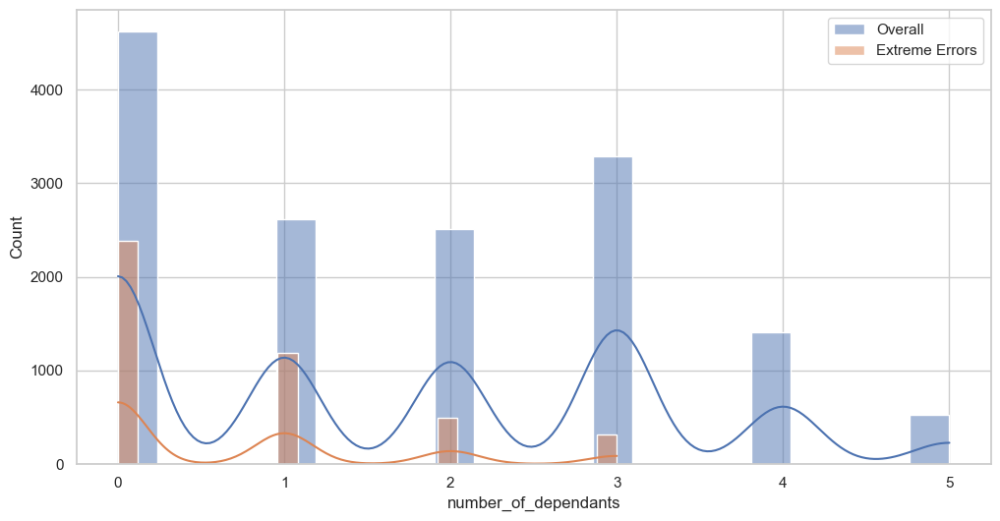

...

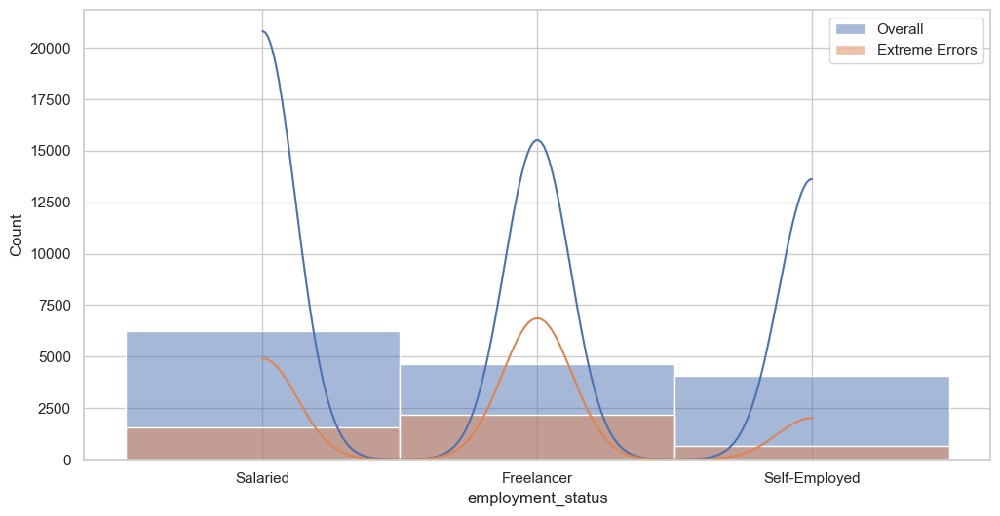

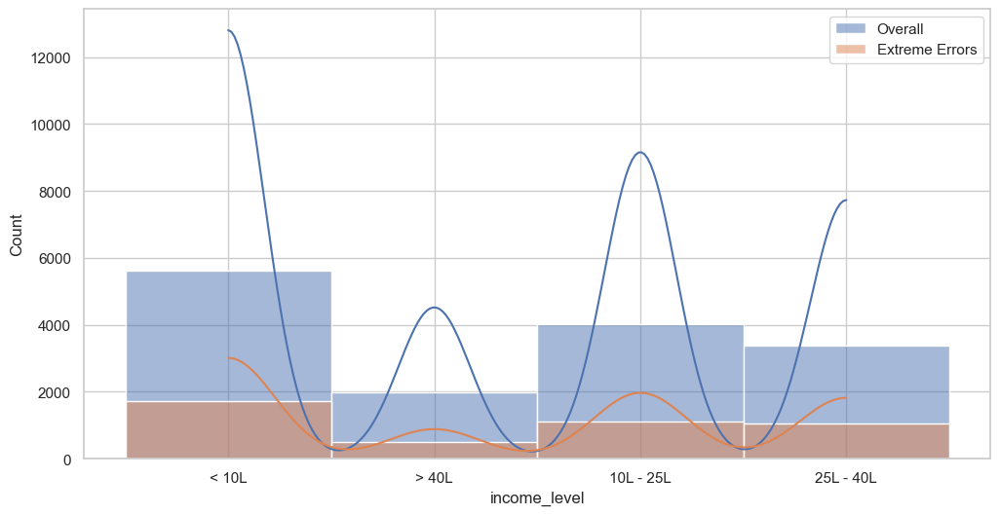

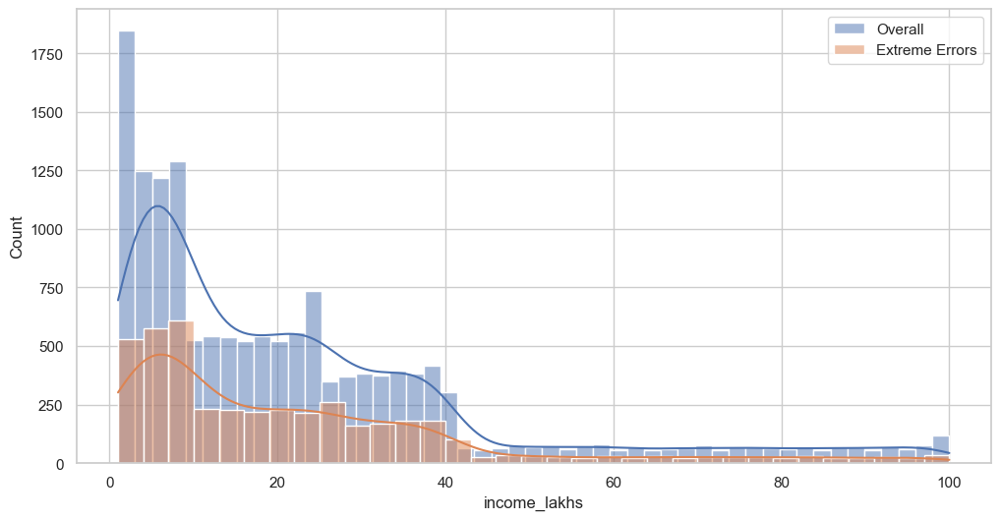

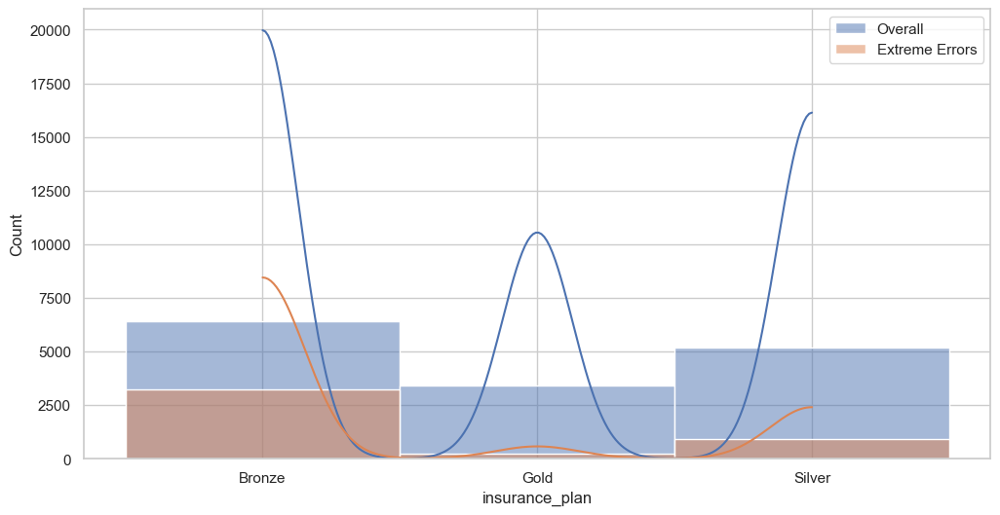

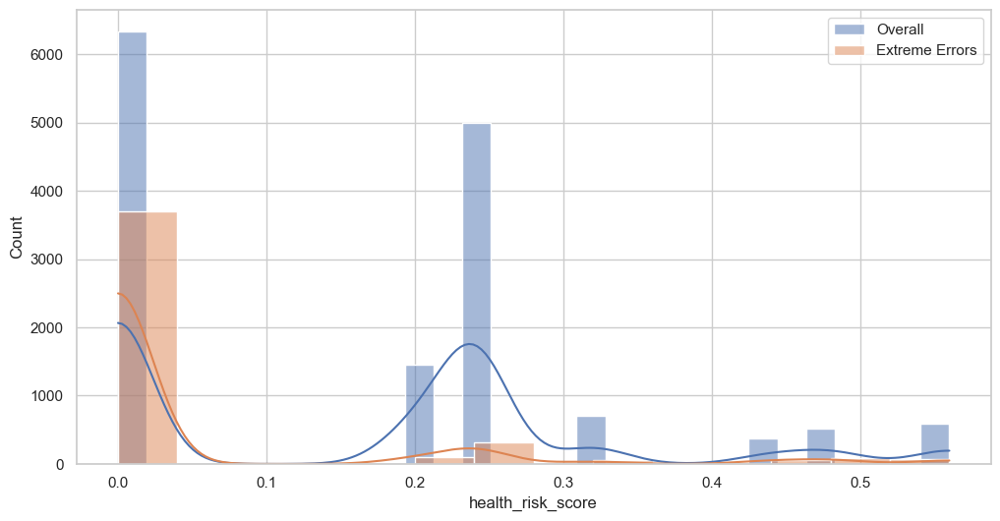

In [254]:
for feature in errors_df.columns:
    plt.figure(figsize=(12,6))
    sns.histplot(X_test[feature], label='Overall', kde=True)
    sns.histplot(errors_df[feature], label='Extreme Errors', kde=True)
    plt.legend()
    plt.show()

<Axes: xlabel='age', ylabel='Count'>

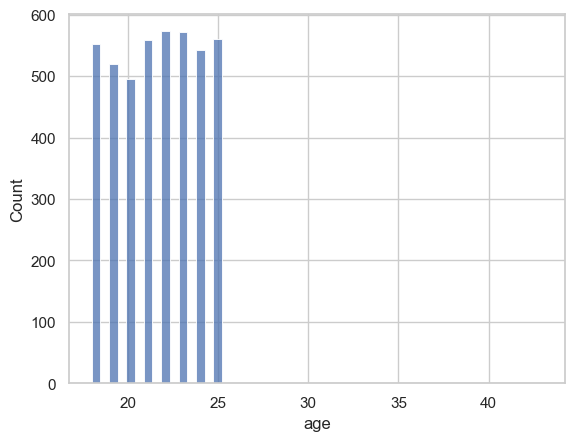

In [259]:
sns.histplot(errors_df['age'])

In [268]:
errors_df['age'].quantile(0.999)

25.0

- `Overwhelming majority of extreme errors are from the population with age<=25. We need to build a separate model for this group.`

##### Exporting the data for population with age>25

In [269]:
tempDF = checkpoint_df.copy()
tempDF

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,health_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,< 10L,6,Bronze,9053,0.24
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,< 10L,6,Bronze,16339,0.24
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,Silver,18164,0.24
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,Gold,20303,0.00
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,Silver,13365,0.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49903,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,Bronze,9111,0.00
49904,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Gold,27076,0.20
49905,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,Bronze,8564,0.00
49906,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,Bronze,9490,0.00


In [ ]:
tempDF[tempDF['age']>25].reset_index(drop=True).to_csv('training_data/old_population.csv', index=False)

In [ ]:
tempDF = pd.read_csv('training_data/old_population.csv')
tempDF

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,health_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,< 10L,6,Bronze,9053,0.24
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,< 10L,6,Bronze,16339,0.24
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,Silver,18164,0.24
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,Gold,20303,0.00
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Bronze,15610,0.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29817,60,Female,Northwest,Married,3,Normal,No Smoking,Self-Employed,25L - 40L,26,Gold,26370,0.24
29818,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,10L - 25L,16,Gold,29496,0.44
29819,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,< 10L,4,Bronze,10957,0.00
29820,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Gold,27076,0.20


#### __`Rough Work`__

In [127]:
df.groupby('gender').describe()

age                                                       \
          count       mean        std   min   25%   50%   75%    max   
gender                                                                 
Female  22520.0  34.619538  15.011466  18.0  22.0  31.0  45.0  356.0   
Male    27480.0  34.572125  14.991633  18.0  22.0  31.0  45.0  356.0   

       number_of_dependants            ... income_lakhs         \
                      count      mean  ...          75%    max   
gender                                 ...                       
Female              22520.0  1.715853  ...         31.0  930.0   
Male                27480.0  1.708988  ...         32.0  900.0   

       annual_premium_amount                                              \
                       count          mean          std     min      25%   
gender                                                                     
Female               22520.0  15166.294316  8040.157883  3501.0  8563.00   
Male                 27480.0  16261.312518  8687.790740  3503.0  8650.75   

                                    
            50%       75%      max  
gender                              
Female  13100.0  21102.75  43119.0  
Male    14946.5  22827.25  43471.0  

[2 rows x 32 columns]

In [131]:
df.groupby('gender')[['annual_premium_amount','age','number_of_dependants']].describe()

annual_premium_amount                                              \
                       count          mean          std     min      25%   
gender                                                                     
Female               22520.0  15166.294316  8040.157883  3501.0  8563.00   
Male                 27480.0  16261.312518  8687.790740  3503.0  8650.75   

                                        age             ...               \
            50%       75%      max    count       mean  ...   75%    max   
gender                                                  ...                
Female  13100.0  21102.75  43119.0  22520.0  34.619538  ...  45.0  356.0   
Male    14946.5  22827.25  43471.0  27480.0  34.572125  ...  45.0  356.0   

       number_of_dependants                                               
                      count      mean       std  min  25%  50%  75%  max  
gender                                                                    
Female              22520.0  1.715853  1.496458 -3.0  0.0  2.0  3.0  5.0  
Male                27480.0  1.708988  1.499733 -3.0  0.0  2.0  3.0  5.0  

[2 rows x 24 columns]

In [133]:
df.groupby(['gender','income_level'])[['annual_premium_amount','age','number_of_dependants']].describe()

annual_premium_amount                                     \
                                    count          mean          std     min   
gender income_level                                                            
Female 10L - 25L                   5176.0  16027.280912  8827.657513  3516.0   
       25L - 40L                   4565.0  16796.653450  9011.459864  3503.0   
       < 10L                       9761.0  12841.575351  6226.465498  3501.0   
       > 40L                       3018.0  18742.346587  8062.542879  3546.0   
Male   10L - 25L                   8321.0  17331.123543  9048.063639  3505.0   
       25L - 40L                   6728.0  17017.166023  9314.885410  3503.0   
       < 10L                       8919.0  12911.802220  6424.218189  3523.0   
       > 40L                       3512.0  20784.946469  8537.002262  3508.0   

                                                              age             \
                          25%      50%       75%      max   count       mean   
gender income_level                                                            
Female 10L - 25L      8045.00  15517.5  22585.25  43119.0  5176.0  34.622875   
       25L - 40L      8369.00  16158.0  24375.00  38762.0  4565.0  35.237021   
       < 10L          8243.00  11009.0  17737.00  37042.0  9761.0  34.613359   
       > 40L         11205.50  19658.0  25996.00  41317.0  3018.0  33.699801   
Male   10L - 25L      8722.00  17359.0  24347.00  43471.0  8321.0  35.133157   
       25L - 40L      8207.75  17004.5  24448.25  41556.0  6728.0  34.531361   
       < 10L          7895.00  11636.0  17176.00  35635.0  8919.0  33.377509   
       > 40L         12080.00  22891.5  27637.50  41461.0  3512.0  36.354784   

                     ...              number_of_dependants            \
                     ...   75%    max                count      mean   
gender income_level  ...                                               
Female 10L - 25L     ...  45.0  356.0               5176.0  1.717543   
       25L - 40L     ...  47.0  356.0               4565.0  1.710624   
       < 10L         ...  45.0  356.0               9761.0  1.727282   
       > 40L         ...  44.0  203.0               3018.0  1.683897   
Male   10L - 25L     ...  45.0  356.0               8321.0  1.764331   
       25L - 40L     ...  45.0  356.0               6728.0  1.690696   
       < 10L         ...  43.0  356.0               8919.0  1.646149   
       > 40L         ...  48.0  356.0               3512.0  1.772494   

                                                        
                          std  min  25%  50%  75%  max  
gender income_level                                     
Female 10L - 25L     1.492982 -3.0  0.0  2.0  3.0  5.0  
       25L - 40L     1.503191 -3.0  0.0  2.0  3.0  5.0  
       < 10L         1.495897 -3.0  0.0  2.0  3.0  5.0  
       > 40L         1.494265 -3.0  0.0  2.0  3.0  5.0  
Male   10L - 25L     1.502036 -3.0  0.0  2.0  3.0  5.0  
       25L - 40L     1.504037 -3.0  0.0  2.0  3.0  5.0  
       < 10L         1.487605 -3.0  0.0  1.0  3.0  5.0  
       > 40L         1.509980 -1.0  0.0  2.0  3.0  5.0  

[8 rows x 24 columns]

`This one is important`

In [54]:
print(pd.crosstab(df['marital_status'], df['employment_status']), '\n')

print(df.groupby(['marital_status','employment_status'])['employment_status'].count().unstack(), '\n')

print(df[['marital_status','employment_status']].value_counts().unstack(), '\n')

employment_status  Freelancer  Salaried  Self-Employed
marital_status                                        
Married                  4913     10880           8526
Unmarried               10515     10090           5076 

employment_status  Freelancer  Salaried  Self-Employed
marital_status                                        
Married                  4913     10880           8526
Unmarried               10515     10090           5076 

employment_status  Freelancer  Salaried  Self-Employed
marital_status                                        
Married                  4913     10880           8526
Unmarried               10515     10090           5076 



/var/folders/l6/8b66p4052jxb1fc9rrzjy4mc0000gn/T/ipykernel_28442/59587976.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['marital_status','employment_status'])['employment_status'].count().unstack(), '\n')


In [55]:
df[['employment_status','income_level']].value_counts().unstack()

income_level,10L - 25L,25L - 40L,< 10L,> 40L
employment_status,,,,
Freelancer,3711,4027,5822,1868
Salaried,6101,3135,9218,2516
Self-Employed,3685,4131,3640,2146


In [ ]:
#   np.percentile(df['Age'],[0,25,50,75,100])
#   np.quantile(df['Age'],[0.00,0.25,0.50,0.75,1.00])

In [84]:
df[num_features].corr()

,age,number_of_dependants,income_lakhs,annual_premium_amount
age,1.000000,0.415773,0.025093,0.767594
number_of_dependants,0.415773,1.000000,0.006171,0.414810
income_lakhs,0.025093,0.006171,1.000000,0.243105
annual_premium_amount,0.767594,0.414810,0.243105,1.000000


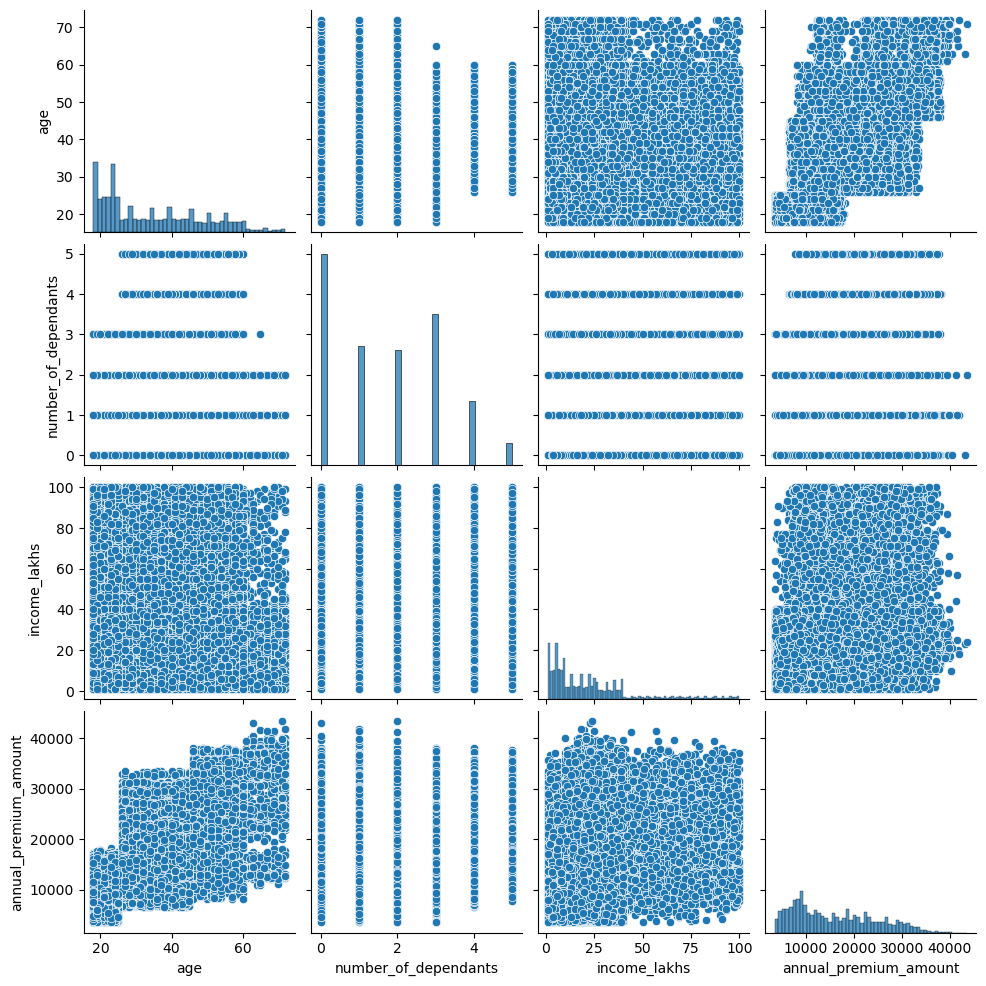

In [78]:
sns.pairplot(df, kind='scatter')

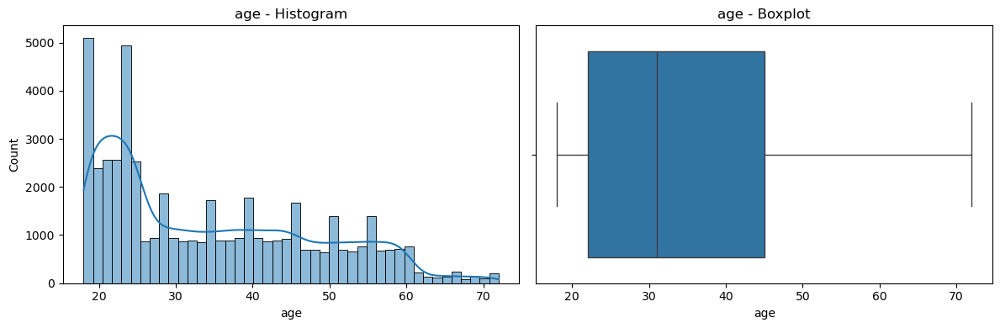

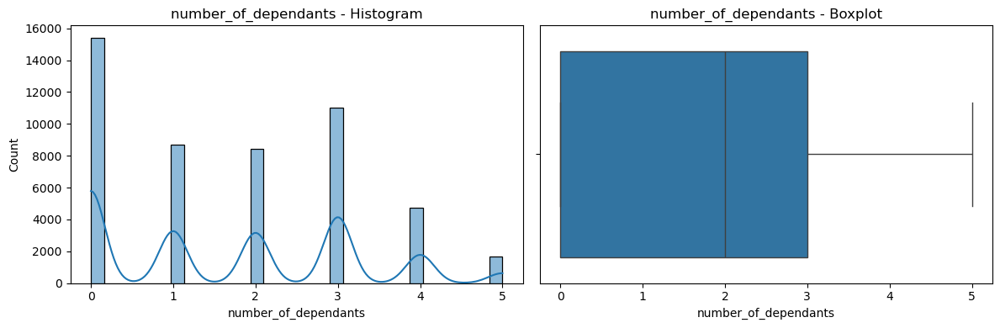

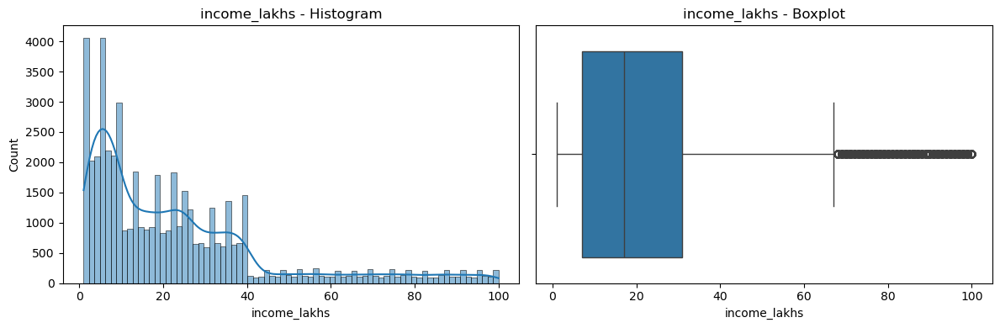

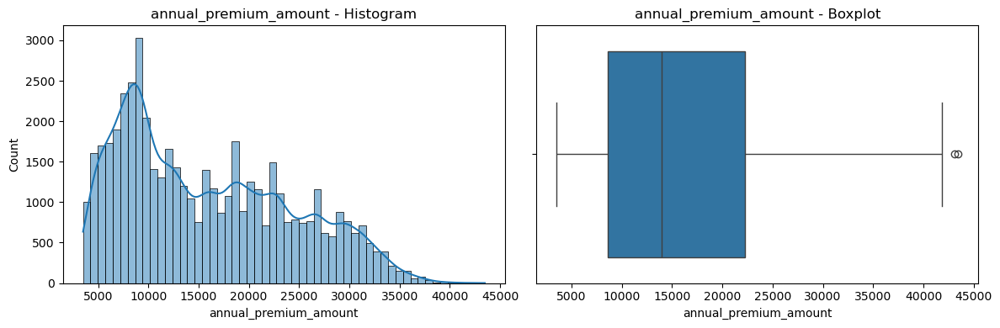

In [94]:
# for feature in num_features:
#     sns.histplot(df[feature], kde=True)
#     plt.show()
#     sns.boxplot(df[feature])
#     plt.show()
#     print('\n')

for feature in num_features:
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[feature], kde=True, ax=axes[0])
    axes[0].set_title(f'{feature} - Histogram')

    sns.boxplot(x=df[feature], ax=axes[1])
    axes[1].set_title(f'{feature} - Boxplot')

    plt.tight_layout()
    plt.show()
    print('\n')

In [93]:
df.groupby('age')['annual_premium_amount'].mean().tail(20)

age
53    25416.927162
54    25596.278732
55    25264.137519
56    25014.637500
57    25377.609649
58    25577.485021
59    25182.933428
60    23879.280884
61    29041.613861
62    29202.344538
63    29354.078125
64    28385.603604
65    28273.701493
66    28715.034783
67    29818.064516
68    28456.635294
69    28812.036765
70    27967.884615
71    29249.105769
72    29141.970588
Name: annual_premium_amount, dtype: float64